In [59]:
# Timo's code for qudi
#see user_scripts -> Timo -> own -> PostProcess_qudiplotter

# Library and load data

## Library

In [6]:
import pandas as pd
import os.path
import math
import numpy as np 
from core.util.math import compute_ft
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime
import copy as cp
from enum import Enum
from scipy.linalg import sqrtm


#import script to read file
exec(open('C:/Users/Setup3-PC/Desktop/qudi/user_scripts/Timo/own/console_toolkit.py').read())

#from user_scripts.Timo.own.console_toolkit import Tk_file, Tk_string
exec(open('C:/Users/Setup3-PC/Desktop/qudi/user_scripts/Timo/own/console_toolkit.py').read())
from logic.pulsed.predefined_generate_methods.multi_nv_methods import DQTAltModes, TomoRotations, TomoInit

import logging
logging.basicConfig(filename='logfile.log', filemode='w', level=logging.DEBUG)
logger = logging.getLogger(__name__)

plt.rcParams.update()
0

ModuleNotFoundError: No module named 'core'

In [7]:
default_params = {'legend.fontsize': 'medium',
          'figure.figsize': (6, 4),
         'axes.labelsize': 12,
         'axes.titlesize':'x-large',
         'xtick.labelsize':12,
         'ytick.labelsize':12,
         'font.size': 12}
plt.rcParams.update(default_params)

NameError: name 'plt' is not defined

In [8]:
class CommonPlt(object):
    def __init__(self):
        self.perform_save = True
        self.save_csv = True
        
        self.save_extension = 'svg'
        self._savepath =  r"C:\Users\Timo\Desktop\_paper_figs\\"
        self._cmap_n_bins= [5,100]
    
    def _save_fig_data(self, fig, name):
        axs = fig.get_axes()

        data = []
        for ax in axs:
            lines = ax.get_lines()
            scatters = ax.collections
            d = [{'x': l.get_xdata(), 'y': l.get_ydata(), 'label': l.get_label()} for l in lines]
            data.extend(d)
            
            # scatter plots
            d = [{'x': s.get_offsets()[:,0], 'y':s.get_offsets()[:,1], 'label': s.get_label()} for s in scatters]
            data.extend(d)
            
        fname = plt_settings.get_savepath(name, extension='csv')
        df = pd.DataFrame(data)
        df.to_csv(fname)
        logger.debug(f"Saved fig data to: {fname}")

    
    def savefig(self, name, save_csv=None, frame_left_inch=2*0.35, frame_bottom_inch=2.5*0.22, 
                frame_top_inch=None, frame_right_inch=None):
        
        if save_csv is None:
            save_csv = self.save_csv
        
        fig = plt.gcf()
        fig_size = fig.get_size_inches()
        
        # make the frame size fixed in inches
        # specify relative to figsize in function
        
        left_rel = frame_left_inch/fig_size[0]
        if frame_right_inch is None:
            right_rel = 1.15*(1 - left_rel)
        else:
            right_rel = 1 - (frame_right_inch/fig_size[0])

        bottom_rel = frame_bottom_inch/fig_size[1]
        if frame_top_inch is None:
            top_rel = 1.05*(1 - bottom_rel)
        else:
            top_rel = 1 - (frame_top_inch/fig_size[1])

        plt.subplots_adjust(left=left_rel, right=right_rel,
                            top=top_rel, bottom=bottom_rel)

        # overwrite tight_layout parameters and save with a fixed frame
        if save_csv:
            self._save_fig_data(fig, name)
        plt.savefig(plt_settings.get_savepath(name))

    def get_markersize(self, size='medium', is_scatter=False, rel_to_fig=True):
        # https://stackoverflow.com/questions/14827650/pyplot-scatter-plot-marker-size
        size_dict = {'small':2, 's-medium':4, 'medium': 5, 'big': 7}
        
        scale_fac = 1
        if rel_to_fig:
            fig = plt.gcf()
            fig_size = fig.get_size_inches()
            fig_size_default = plt.rcParams['figure.figsize']
            
            idx = np.argmax(np.abs(fig_size/fig_size_default - 1))
            scale_fac = (fig_size/fig_size_default)[idx]
        
        if is_scatter:
            return (scale_fac*size_dict[size])**2
        
        return scale_fac*size_dict[size]
        
    def get_savepath(self, fname, extension=None):
        
        fname = fname.replace(".png","").replace(".svg","svg")
        if extension is None:
            extension = self.save_extension
        
        if not self.perform_save:
            return ""
        return self._savepath + fname + "." + extension
    
    def get_cmap(self, continuous=True):
        cmaps = self._create_cmap()
        cmap = None
        
        for key, val in cmaps.items():
            if continuous:
                if not 'cont' in key:
                    continue
            else:
                 if 'cont' in key:
                    continue
            cmap = val
        
        return cmap
    
    def color(self, colorstr=None, alpha=1):
        color_map = {'blue':0, 'bluelight':1, 'red':4, 'green':2, 'orange':3}
        if colorstr is not None:
            if colorstr == 'grey':
                # handle grey outside of color cycle, #a9a28dff
                return tuple([0.6627, 0.63529, 0.5529, alpha])
            if colorstr not in color_map.keys():
                raise ValueError
            else:
                color = self.get_cmap(False)(color_map[colorstr])

                color_alpha = list(color)[0:3]
                color_alpha.append(alpha)
                
                return tuple(color_alpha)
            
    def marker_style(self, color, is_scatter=False, is_err=False, size='medium'):
        marker_style = dict(marker='o',
                            color=color,
              )
        
        err_style = dict(capthick=1, elinewidth=1, capsize=1.5)
        
        
        if is_scatter:
              marker_style = {**dict(s=plt_settings.get_markersize(is_scatter=True, size=size),
                                    facecolor=color,
                                    linewidths=1,
                                    edgecolor='grey'), **marker_style}
            
        elif not is_scatter and not is_err:
             marker_style = {**dict(markersize=plt_settings.get_markersize(is_scatter=False, size=size),
                                    markerfacecolor=color,
                                    markeredgewidth=1,
                                    markeredgecolor='grey',
                                    linestyle=''), **marker_style}
        
        elif is_err:
             marker_style.update(err_style)
        else:
            raise ValueError
        
        return marker_style
    
    def _create_cmap(self):
        colors_uulm = ['#26547c', '#7d9aaa', '#56aa1c', '#df6d07', '#a32638']#, '#a9a28d'] 
        n_bins = self._cmap_n_bins  # Discretizes the interpolation into bins

        cmap_name = ['uulm_5', 'uulm_cont']
        idx = 0
        
        cmaps = {}
        for n_bin in n_bins:
            # Create the colormap
            cmap = LinearSegmentedColormap.from_list(cmap_name[idx], colors_uulm, N=n_bin)
            cmaps[cmap_name[idx]] = cmap
            idx += 1
            
        return cmaps        
    

try:
    plt_settings = CommonPlt()
    
except:
    logger.exception("")

0

0

In [9]:
import lmfit

def setup_clear_plots(n_plots):
    n_cur = qdplotlogic.number_of_plots
    for i in range(n_cur):
        n_cur_i = qdplotlogic.number_of_plots
        if n_cur_i >= 1:
            # removing without arguments seems buggy
            qdplotlogic.remove_plot(n_cur_i-1)
    
    for i in range(n_plots):
        qdplotlogic.add_plot()
def extract_num_from_path(file):
    fname = os.path.basename(file)
    res = Tk_string.find_num_in_str(fname)
    
    return res

"""
# delete if Tk_file import works
def load_pulsed_result(fname):

    data = pd.read_csv(fname, sep="\t", comment='#', names=["tau", "z1", "z2", "std1", "std2"])
    if pd.isnull(data.iloc[0, -1]):
        data = pd.read_csv(fname, sep="\t", comment='#', names=["tau", "z1", "std1"])
    meta = Tk_file.load_pulsed_metadata(fname)

    mes = {'data': data,
           'file': fname}
    mes = {**mes, **meta}

    return mes
"""
def do_fit(p_mes, fit_y='delta', fit_method='sine', edit_params=None, settings=None):
    fitter = pulsedmeasurementlogic.fc   
    
    if edit_params:
        for ov_param in edit_params:
            
            if ov_param.name in fitter.fit_list[fit_method]['parameters'].keys():
                fitter.fit_list[fit_method]['use_settings'][ov_param.name] = True
                fitter.fit_list[fit_method]['parameters'][ov_param.name] = ov_param
                
                #logger.debug(f"Overwriting fit param {ov_param.name}: {ov_param}")

    fitter.clear_result()
    fitter.set_current_fit(fit_method)
    """
    x_fit, y_fit, result = fitter.do_fit(data[0], data[1])
    result = result.result_str_dict

    """

    if fit_y == 'delta':
        data = np.asarray(p_mes['data']['tau']), np.asarray(delta_or_z1(p_mes))
    elif fit_y == 'z1':
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data']['z1'])
    elif fit_y == 'z2':
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data']['z2'])
    else:
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data'][fit_y])
        
    
    slice_idx = slice(0, None)
    if settings:
        if 'slice_data' in settings.keys():
            slice_idx = settings['slice_data']
            
    x_fit, y_fit, result = fitter.do_fit(data[0][slice_idx], data[1][slice_idx])
    # params [lmfit::Parameters] and derived params [dict]
    # considered in _get_fit()
    
    # get values of fitted model
    model = fitter.fit_list[fit_method]['make_model']()[0]
    
    x_domain = np.asarray(p_mes['data']['tau'])
    x_domain = np.linspace(np.min(x_domain), np.max(x_domain), 1000)
    if settings:
        if 'fit_range' in settings.keys():
            x_domain = settings['fit_range']

    y = model.eval(x=x_domain, params=result.params)
    fit_vals = {'x': x_domain, 
                'y': y}
    
    full_result = {**result.params, **result.result_str_dict}
    p_mes['fit_res'] = full_result
    p_mes['fit_values'] = fit_vals
    
    reset_fitter(fit_method, edit_params)

def reset_fitter(fit_method=None, edit_params=None):
    fitter = pulsedmeasurementlogic.fc   
    
    if edit_params:
        for ov_param in edit_params: 
            if ov_param.name in fitter.fit_list[fit_method]['parameters'].keys():
                fitter.fit_list[fit_method]['use_settings'][ov_param.name] = False   
    
    
def get_z(p_mes, mode='z1'):
    # mode: z1, z2, delta, (+_norm)
    try:
        has_z2 = True
        try:
            p_mes['data']['z2']
        except KeyError:
            has_z2 = False
            
        tau = p_mes['data']['tau']
        z1 = p_mes['data']['z1']
        z1_norm = z1/np.average(z1)
        dz1 = p_mes['data'].get('std1')
        dz2 = p_mes['data'].get('std2')
        
        if mode == 'z1':
            return z1, dz1
        elif mode == 'z1_norm':
            return z1_norm, dz1/z1*z1_norm
        elif mode == 'z2' or mode == 'z2_norm' or mode=='delta' or mode=='delta_norm':
            if has_z2:
                z2 = p_mes['data']['z2']
                delta = (z1-z2)
                delta_norm = delta/np.average(z1)
            else:
                raise KeyError
                
            if mode == 'z2':
                return z2, dz2
            if mode == 'z2_norm':
                return z2/np.average(z2), dz2/z2*z2_norm
            if mode == 'delta':
                return delta#, np.sqrt(dz1**2+dz2**2)
            if mode == 'delta_norm':
                return delta_norm, np.sqrt(dz1**2+dz2**2)/delta * delta_norm
        else:
            raise ValueError(f"Unknown mode: {mode}")  

    except:
        logger.exception(f"Loading of {mode} from file {p_mes['file']} failed")
        raise  

def delta_or_z1(p_mes, norm=False):
    try:
        
        ret = None
        
        has_delta = True
        try:
            delta = p_mes['data']['delta']
            ret = delta
        except KeyError:
            has_delta = False
            
        
        has_z2 = True
        try:
            z2 = p_mes['data']['z2']
        except KeyError:
            has_z2 = False
        
        try:
            z1 = p_mes['data']['z1']
        except KeyError:
            pass

        if has_z2 and not has_delta:
            delta = (z1-z2)
            ret = delta

        if norm:
            return ret/np.average(ret)
        return ret
    except:
        logger.exception(f"Loading of file {p_mes['file']} failed: {p_mes['data']}")
        raise


def pulsed_series_2_array(pulsed_series, idx_var_y=None, ordered_y=True):
    y2d = []
    z1s, z2s = [], []
    x2d = []

    for p in p_raw:
        try:
            z1 = p['data']['z1']
            try:
                z2 = p['data']['z2']
            except:
                z2 = np.nan
            # set x axis of 2d plot
            tau = p['data']['tau']
            # set y axis of 2d plot
            idx_file = extract_num_from_path(p['file'])[-2]
            if idx_var_y != None:
                if type(idx_var_y) == list:
                    var_file = [float(extract_num_from_path(p['file'])[idx]) for idx in idx_var_y]
                else:
                    var_file = float(extract_num_from_path(p['file'])[idx_var_y])
            # set y axis as time of mes
            if idx_var_y == None:
                var_file = p['date'].timestamp() - p_raw[0]['date'].timestamp()
            #logger.info(f"1st: tau {tau}, x2d {x2d}")
            if len(x2d) > 0:
                err = f"Data in file {p['file']} doesn't share tau axis"
                try:
                    if not np.all(x2d == tau):
                        raise ValueError(err)
                except:
                    logger.exception(err)
                    raise


            x2d = tau
            #logger.info(f"tau {tau}, x2d {x2d}")
            y2d.append(var_file)
            z1s.append(z1)
            z2s.append(z2)

        except:
            logger.exception(f"Loading of file {p['file']} failed")
            raise



    z1s = np.asarray(z1s)
    z2s = np.asarray(z2s)

    x2d = np.asarray(x2d)
    y2d = np.asarray(y2d)
    
    if ordered_y:
        y2d,  z1s, z2s = np.sort(y2d), z1s[y2d.argsort()], z2s[y2d.argsort()]
    
    return x2d, y2d, z1s, z2s


def pulsed_series_2_1d_fit_array(pulsed_series, fit_meth, fit_on, fit_vals,
                                 idx_var_x=None, ordered_x=True):
    
    init_dict = {idx: [] for idx in range(len(fit_vals))}
    
    x, infos = [], []
    ys, dys = init_dict, cp.deepcopy(init_dict)
    
    for idx, p in enumerate(pulsed_series):
        if idx % 10 == 0:
            logger.debug(f"Fitting {idx}/{len(pulsed_series)}")
        if uglobals.abort.is_set():
            break
        try:
            # set x axis of 1d plot
            # idx_file = extract_num_from_path(p['file'])[-2]
            if idx_var_x:
                var_file = float(extract_num_from_path(p['file'])[idx_var_x])
            # set y axis as time of mes
            else:
                var_file = p['date'].timestamp() - pulsed_series[0]['date'].timestamp()
            x.append(var_file)
            
            # looks for fit params to overwirte
            edit_params, settings = None, None
            if 'fit_edit_params' in p.keys():
                edit_params = p['fit_edit_params']
            if 'fit_settings' in p.keys():
                settings = p['fit_settings']
            
            # fit result on y axis
            do_fit(p, fit_y=fit_on, fit_method=fit_meth,
                   edit_params=edit_params, settings=settings)
            
            for i in range(len(fit_vals)):
                ys[i].append(_get_fit(p, i, error=False, cust_vals=fit_vals))
                dys[i].append(_get_fit(p, i, error=True, cust_vals=fit_vals))
            
            infos.append({'file': p['file']})
        except:
            logger.exception(f"Loading of file {p['file']} failed")
            raise
            
    x = np.asarray(x)

    for i in range(len(fit_vals)):
        ys[i] = np.asarray(ys[i])
        dys[i] = np.asarray(dys[i])

    if ordered_x:
        infos = np.asarray(infos, dtype=object)
        infos = infos[x.argsort()]
        for i in range(len(fit_vals)):
            x, ys[i] = np.sort(x), ys[i][x.argsort()]
            dys[i] = dys[i][x.argsort()]
    
    return x, ys, dys, infos

def _get_fit(p, y_idx=0, error=False, cust_vals=None):
    import lmfit
    fit_vals = ['Lifetime', 'Contrast', 'Frequency']
    if cust_vals:
        fit_vals = cust_vals
    try:
        param = p['fit_res'][fit_vals[y_idx]]
        if isinstance(param, lmfit.parameter.Parameter):
            fit_quant = 'stderr' if error else 'value'
            return getattr(param, fit_quant)
        elif isinstance(param, dict):
            fit_quant = 'error' if error else 'value'
            return param[fit_quant]
        else:
            raise ValueError(f"Didn't understand fit param type: {type(params)}")
    except:
        return -1
0

0

In [10]:
import pandas as pd
import difflib


def overwrite_poi_from_foldername(p_mes):
    # needed, if "Active POI:" property in .dat file is buggy
    path = os.path.normpath(p_mes['file'])
    poi = path.split(os.sep)[-2][:]
    try:
        poi = 'nv_' + poi.rsplit('nv_',1)[1]
    except IndexError:
        return
    #return poi
    #poi.rsplit(poi, '')
    
    if 'Pulsed' in poi:
        return
    else:
        p_mes['poi'] = poi
        return poi

def find_param_file(p_mes):
    return Tk_file.find_param_file(p_mes)

def extract_params_from_file(header_lines):

    header_flat = ' '.join([line for line in header_lines])
    text = header_flat

    # time of experiment
    m = re.search('on(.+?)\n', text)
    if m:
        found = m.group(1)
    date = pd.to_datetime(found, dayfirst=True)

    # poi
    m = re.search('POI:(.+?)\n', text)
    if m:
        found = m.group(1)
    poi = found.lstrip()

    meta = {'date': date,
            'poi': poi}
    return meta

    
def load_param_file(fname):
        
    return Tk_file.load_param_file(fname)

def load_pulsed_params(p_mes):
    fname = find_param_file(p_mes)
    return load_param_file(fname)
    
def decay_fit(p_in, name_timeconst='T2_he', fit_meth='exp_decay'):
    y_val_idx = None
    fit_on = 'delta'
    fit_vals = ['Lifetime', 'None', 'None']
    
    x, ys, dys, _ = pulsed_series_2_1d_fit_array(p_in, 
                                                fit_meth=fit_meth, fit_on=fit_on, fit_vals=fit_vals,
                                                idx_var_x=y_val_idx, ordered_x=True)
    y, y2, y3  = ys[0], ys[1], ys[2]
    dy, dy2, dy3 = dys[0], dys[1], dys[2]
    
    for p in p_in:
        p[f"fit_res_{name_timeconst}"] = p['fit_res']

def nv_class_for_exp(p_in, f_res_classes=[2.907e9, 2.963e9, 3.029e9, 3.087e9]):
    for p in p_in:
        try:
            f_mw = load_pulsed_params(p)['microwave_frequency']
            p['exp_on_fres'] = NVClass(find_closest(f_mw, f_res_classes=f_res_classes))
        except KeyError:
            pass
            

def find_best_lor_fit(p_in, fit_meths=['lor_dip', 'lor_dip_2x']):
    
    for i, fmeth in enumerate(fit_meths):
        y_val_idx = None
        fit_on = 'z1'
        fit_meth = fmeth
        fit_vals = ['Position 0', 'Position 1', 'Position 2']    
        if i == 0:
            fit_vals[0] = 'Position'
        
        x, ys, dys, _ = pulsed_series_2_1d_fit_array(p_in, 
                                                        fit_meth=fit_meth, fit_on=fit_on, fit_vals=fit_vals,
                                                        idx_var_x=y_val_idx, ordered_x=True)
        y, y2, y3  = ys[0], ys[1], ys[2]
        dy, dy2, dy3 = dys[0], dys[1], dys[2]
        
        for p in p_in:
            p[f"fit_res_{fmeth}"] = p['fit_res']

        """
        # fit_res is updated after

        y_val_idx = None
        fit_on = 'z1'
        fit_meth = fit_meths[1]
        fit_vals = ['Position 0', 'Position 1', 'None']    

        x, y, y2, y3, dy = pulsed_series_2_1d_fit_array(p_in, 
                                                    fit_meth=fit_meth, fit_on=fit_on, fit_vals=fit_vals,
                                                    idx_var_x=y_val_idx, ordered_x=True)
        for p in p_in:
            p[f"fit_res_{fit_meths[1]}"] = p['fit_res']
        """

from enum import IntEnum        
class NVClass(IntEnum):
    NOT_CLASSIFIED = -1
    NO_ODMR = -2
    A = 0
    B = 1
    C = 2
    D = 3

    
def classify_nv_orientation(p_mes, fit_meths=['lor_dip', 'lor_dip_2x'],
                            f_res_classes=[2.907e9, 2.963e9, 3.029e9, 3.087e9], snr_thresh=10):
    """
    fit meths should be ordered in the number of nvs they correscpond.
    -> lor_dip, lor_dip_2x => n=[1,2]
    """
    p = p_mes
    nv_class = None
    
    chis = []
    for fit in fit_meths:
        if f"fit_res_{fit}" in p.keys():
            chis.append(p[f"fit_res_{fit}"]['chi_sqr']['value'])
    
    i_chi = np.argmin(np.asarray(chis)) 
    n_nv = i_chi + 1
    nv_classes = []
    
    for i_line in range(0, n_nv):
        if n_nv <= 1:
            f_res_i = p[f"fit_res_{fit_meths[0]}"]['Position']['value']
        else:    
            f_res_i = p[f"fit_res_{fit_meths[i_chi]}"][f'Position {i_line}']['value']

        nv_class_i = find_closest(f_res_i, f_res_classes=f_res_classes)
        nv_classes.append(NVClass(nv_class_i))
    
    for i_line in range(0, n_nv):
        if not classify_has_odmr(p, nv_classes, fit_meths=fit_meths, snr_thresh=snr_thresh)[i_line]:
            nv_classes[i_line] = NVClass.NO_ODMR

    """
    # smaller chisqr: better fit
    if chisqr_0 < chisqr_1:
        f_res = p[f"fit_res_{fit_meths[0]}"]['Position']['value']
        nv_class = [NVClass(find_closest(f_res, f_res_classes=f_res_classes))]
        if not classify_has_odmr(p, nv_class, fit_meths=fit_meths, snr_thresh=snr_thresh)[0]:
            nv_class = [NVClass.NO_ODMR]

    else:
        f_res_0 = p[f"fit_res_{fit_meths[1]}"]['Position 0']['value']
        f_res_1 = p[f"fit_res_{fit_meths[1]}"]['Position 1']['value']
        nv_class_0 = find_closest(f_res_0, f_res_classes=f_res_classes)
        nv_class_1 = find_closest(f_res_1, f_res_classes=f_res_classes)

        nv_class = [NVClass(nv_class_0), NVClass(nv_class_1)]

        if not classify_has_odmr(p, nv_class, fit_meths=fit_meths, snr_thresh=snr_thresh)[0]:
            nv_class[0] = NVClass.NO_ODMR
        if not classify_has_odmr(p, nv_class, fit_meths=fit_meths, snr_thresh=snr_thresh)[1]:
            nv_class[1] = NVClass.NO_ODMR
    """
    return nv_classes
        
def classify_nv_orientation_all(p_in, fit_meths=['lor_dip', 'lor_dip_2x'],
                            f_res_classes=[2.907e9, 2.963e9, 3.029e9, 3.087e9], snr_thresh=10):  
    for p in p_in:
        try:
            nv_class = classify_nv_orientation(p, fit_meths=fit_meths, f_res_classes=f_res_classes, snr_thresh=snr_thresh)
            p['nv_class'] = nv_class
        except:
            raise ValueError(f"Failed classifiying file: {p_in['fname']}")

def calc_odmr_snr_areal(p_mes, nv_class, fit_meths=['lor_dip', 'lor_dip_2x'], linewidth_expect=[3e6, 50e6]):
    
    def punish_wrong_linewidth(fwhm, linewidth_limit=[0,np.inf]):
        if fwhm < linewidth_limit[0] or fwhm > linewidth_limit[1]:
            return fwhm * 0.05
        
        return fwhm
        
    p = p_mes
    n_fres = len(([int(c) for c in nv_class]))
  
    if f"fit_res_{fit_meths[0]}" in p.keys() and f"fit_res_{fit_meths[1]}" in p.keys():
        contr_single = p[f"fit_res_{fit_meths[0]}"]['Contrast']['value']
        contr0 = p[f"fit_res_{fit_meths[1]}"]['Contrast 0']['value']
        contr1 = p[f"fit_res_{fit_meths[1]}"]['Contrast 1']['value']
        fwhm_single = p[f"fit_res_{fit_meths[0]}"]['FWHM']['value']
        fwhm_0 = p[f"fit_res_{fit_meths[1]}"]['FWHM 0']['value']
        fwhm_1 = p[f"fit_res_{fit_meths[1]}"]['FWHM 1']['value']
        y = p['data']['z1']
        
        # todo: ugly hard coded punishment
        fwhm_single = punish_wrong_linewidth(fwhm_single, linewidth_limit=linewidth_expect)
        fwhm_0 = punish_wrong_linewidth(fwhm_0, linewidth_limit=linewidth_expect)
        fwhm_1 = punish_wrong_linewidth(fwhm_1, linewidth_limit=linewidth_expect)
        
        
        signal_single = contr_single * fwhm_single
        signal0 = contr0 * fwhm_0
        signal1 = contr1 * fwhm_1
        
        f_sampling = p['data']['tau'][1] - p['data']['tau'][0]
        # noise in units of contrast
        
        noise_c = 1*np.std(y)/np.mean(y)*100
        noise_area = noise_c * f_sampling
        
        #logger.debug(f"noise: {noise_c}/{noise_area}, signal area: {signal_single}/ {signal0} / {signal1}")
        #logger.debug(f"noise: {noise_c}/{noise_area/1e6}, fwhm: {fwhm_single/1e6}/ {fwhm_0/1e6} / {fwhm_1/1e6}, \
        #             contr {contr_single}, {contr0}, {contr1}")
        
        
        if n_fres <= 1:
            return [signal_single/noise_area] 
        elif n_fres == 2:
            signal = [None, None]
            signal[0] = signal0/noise_area
            signal[1] = signal1/noise_area
            
            return signal
        else:
            raise NotImplemented("Only can handle up to two resonance lines right now")
        
        
def classify_has_odmr(p_mes, nv_class, fit_meths=['lor_dip', 'lor_dip_2x'], snr_thresh=10):
    """
    Compares the fit area against the one from the noise signal
    """
    p = p_mes
    found_odmr = None
 
    n_fres = len(([int(c) for c in nv_class]))
    #logger.debug(f"Got nv class {nv_class} of len {n_fres}")
    
    
    if f"fit_res_{fit_meths[0]}" in p.keys() and f"fit_res_{fit_meths[1]}" in p.keys():

        
        if n_fres <= 1:
            signal_single = calc_odmr_snr_areal(p, nv_class, fit_meths)[0]
            found_odmr = [True] if signal_single > snr_thresh else [False]
        elif n_fres == 2:
            signal0, signal1 = calc_odmr_snr_areal(p, nv_class, fit_meths)
            
            found_odmr = [False, False]
            if signal0 > snr_thresh:
                found_odmr[0] = True
            if signal1 > snr_thresh:
                found_odmr[1] = True
        else:
            raise NotImplemented("Only can handle up to two resonance lines right now")
        
        
    return found_odmr  
        

def get_chisqr(p_mes, fit_meths=['lor_dip', 'lor_dip_2x']):
    p = p_mes
    if f"fit_res_{fit_meths[0]}" in p.keys() and f"fit_res_{fit_meths[1]}" in p.keys():
        chisqr_0 = p[f"fit_res_{fit_meths[0]}"]['chi_sqr']['value']
        chisqr_1 = p[f"fit_res_{fit_meths[1]}"]['chi_sqr']['value']
            
        idx_best_fit = np.argmin([chisqr_0, chisqr_1])
        return np.min([chisqr_0, chisqr_1]), idx_best_fit
    
def find_closest(f_res, f_res_classes=[2.907e9, 2.963e9, 3.029e9, 3.087e9]):
    return np.argmin(np.abs(f_res - np.asarray(f_res_classes)))
        
def get_n_odmr_lines(p_mes):   
    
    p = p_mes
    nv_class = p['nv_class']
    nv_class_unique = set(nv_class)
    n_odmr_lines = len([c for c in nv_class_unique if int(c) >= 0])
    
    return n_odmr_lines

def get_mes_for_nv(poi, all_mes, exp_name=None, nv_class=None):
    
    def by_name(p_mes):
        found = False
        
        if exp_name == None and nv_class == None:
            if p_mes['poi'] == poi:
                found = True
        elif exp_name == None and nv_class != None:
            try:
                if p_mes['poi'] == poi and p_mes['exp_on_fres'] == nv_class:
                    found = True
            except KeyError:
                if nv_class == NVClass.NOT_CLASSIFIED:
                    found = True
        elif exp_name != None and nv_class != None:
            try:
                if p_mes['poi'] == poi and p_mes['exp_on_fres'] == nv_class and p_mes['experiment_name'] == exp_name:
                    found = True
            except KeyError:
                if nv_class == NVClass.NOT_CLASSIFIED:
                    found = True
        else:
            found = True if p_mes['poi'] == poi and p_mes['experiment_name'] == exp_name else False
        
        return found
    
    #if nv_class != None:
    #    logger.debug(f"Called exp_name: {exp_name} nv_class {nv_class}")
            
    return list(filter(by_name, all_mes))

def create_table(p_in_odmr, p_in_dd=[], name_tc_dd=['T2_he', 'T2_xy8'], name_exp_dd=['hahn_echo', 'xy8_n']):
    """
    From lists of basis 'measurement per row' compile an output table with 'nv characteristics' per row
    """
    table = []
    
    p_in_dd_flat = []
    [p_in_dd_flat.extend(p_list) for p_list in p_in_dd] 
    p_in_dd = p_in_dd_flat
        
    for i, p in enumerate(p_in_odmr):
        
        # ODMR
        nv_class = p['nv_class']
        nv_class_unique = set(nv_class) 
        
        # for pretty print, don't repeat non-classified results in output string
        nv_class_str = [c.name for c in nv_class_unique]
        if len(nv_class_str) > 1:
            nv_class_str = [c.name for c in nv_class_unique if int(c) >= 0]
        nv_class_str = str(nv_class_str)
        
        n_odmr_lines = get_n_odmr_lines(p)
        
        fit_chisqr, _ = get_chisqr(p)
        fit_snr_list = calc_odmr_snr_areal(p, nv_class)
        fit_snr_0 = None
        fit_snr_1 = None
        if len(fit_snr_list) == 1:
            fit_snr_0 = fit_snr_list[0]
        elif len(fit_snr_list) == 2:
            fit_snr_0 = fit_snr_list[0]
            fit_snr_1 = fit_snr_list[1]
            
        
        row = {'idx': i,
               'poi': p['poi'], 
               'nv_class': nv_class_str, 
               'nv_class_raw': nv_class, 
               'n_odmr': n_odmr_lines,
               'odmr_chi_sqr': fit_chisqr,
               'date_odmr': p['date']}
        #"""
        if fit_snr_0:
            row['snr_0'] = fit_snr_0
        if fit_snr_1:
            row['snr_1'] = fit_snr_1
        #""" 
        
        # HAHN ECHO
        #for i, exp_list in enumerate(p_in_dd):
        for i, exp_name in enumerate(name_exp_dd):
            try:
                classes = [val for val in NVClass]
                for nv_c in classes:
                    p_dd = get_mes_for_nv(p['poi'], p_in_dd, exp_name, nv_c)
                    val_class = nv_c #if (nv_c != NVClass.) else None 
                    if len(p_dd) == 1:
                        nv_class = p_dd[0]['exp_on_fres'].name
                        label = f'{name_tc_dd[i]} (us)'
                        val = [(1e6*p_dd[0][f"fit_res_{name_tc_dd[i]}"]['Lifetime']['value'], val_class)]
                        if label not in row.keys():
                            row[label] = val                                
                        else:
                            row[label] = row[label] + val
                        #row[f'{name_tc_dd[i]}_nv_class'] = nv_class
                    elif len(p_dd) == 0:
                        pass
                    else:
                        logger.warning(f"Found and ignored > 1 he files for poi {p['poi']}. Filter while loading data!")
            except:
                logger.exception(f"Error on poi {p['poi']}, exp: {exp_name}: ")
                
        table.append(row)
    
    df = pd.DataFrame(table)
      
    return df

def handle_duplicate_all_mes(all_p_mes, mode='newer'):
    new_all = cp.deepcopy(all_p_mes)
    for p in all_p_mes:
        len_old = len(new_all)
        new_all = handle_duplicate_mes(p, new_all, mode=mode)
        #logger.debug(f"for {p['poi']}, {p['date']}, {p['experiment_name']}. len: {len_old} => {len(new_all)}")
    return new_all


def handle_duplicate_mes(p_mes, all_p_mes, mode='newer'):
    # delte duplicates and add to 'all mes' list 
    
    pois = [p['poi'] for p in all_p_mes]
    # for performance, skip if no decision can be made
    if p_mes['poi'] not in pois:
        return all_p_mes
    if p_mes['experiment_name'] == None:
        return all_p_mes
    
    def newer(ex_mes):
        """
        Sort out (return False) elements with same poi && experiment name, but older date
        """
        if ex_mes['poi'] == p_mes['poi'] and ex_mes['experiment_name'] == p_mes['experiment_name']:
            # break if on different nv class
            #"""
            if 'exp_on_fres' in ex_mes.keys() and 'exp_on_fres' in p_mes.keys():
                if ex_mes['exp_on_fres'] != p_mes['exp_on_fres']:
                    return True
            #""" 
            if ex_mes['date'] > p_mes['date']:
                return True
            return False
        else:
            return True
    
    def is_dupl(ex_mes):
        if ex_mes['poi'] == p_mes['poi'] and ex_mes['experiment_name'] == p_mes['experiment_name']:
            if 'exp_on_fres' in ex_mes.keys() and 'exp_on_fres' in p_mes.keys():
                if ex_mes['exp_on_fres'] != p_mes['exp_on_fres']:
                    return False
            if ex_mes['date'] > p_mes['date']:
                return False
            return True
            
        return False
        
    
    if mode == 'newer':
        # delete older mes with same poi && name && orientation (if available)
        all_p_mes = list(filter(newer, all_p_mes))
    elif mode == 'all':
        pass
    else:
        raise ValueError(f"Unknown mode: {mode}")
    
    if mode == 'newer' or mode == 'all':
        if not any(map(is_dupl, all_p_mes)):
            all_p_mes.append(p_mes)    
    
    return all_p_mes

def create_header_comment(settings_dict):
    out_str = f""
    date = datetime.datetime.now().strftime("%Y/%m/%d, %H:%M:%S \n")
    out_str = f"# analysis on: {date}"
    for key, val in settings_dict.items():
        out_str += f"# {key}: {val}"
        out_str += "\n"
    
    return out_str

from collections import Iterable
def float2string(input):
    """convert float to string for printing
    """
    if isinstance(input, Iterable):
        return list(map(float2string, input))
    else:
        if input is None:
            return None
        else:
            if isinstance(input, NVClass):
                return f"{input.name}"
            elif float(input).is_integer():
                return "{}".format(input)
            else:
                return "{:.2f}".format(input)

def mean_of_list(cell):
    if isinstance(cell, Iterable):
        #logger.debug(f"Iterable: {cell}")
        return np.nanmean(list(map(mean_of_list, cell)))
    else:
        if cell is None:
            return 0
        else:
            if isinstance(cell, NVClass):
                return np.nan
            else:
                return float(cell)

def flatten_floats_only(cell):
    def _flatten(cell):
        if isinstance(cell, Iterable):
            #logger.debug(f"Iterable: {cell}")
            a = list(map(_flatten, cell))

            #a = [item for sublist in a for item in sublist]
            return a
        else:
            if cell is None:
                return None
            else:
                if isinstance(cell, NVClass):
                    return None
                else:
                    return float(cell)
    
    a = _flatten(cell)
    a = [item for sublist in a for item in sublist]
    a = [item for sublist in a for item in sublist]
    a = [item for item in a if item != None]
    return a
            
def mean_of_list_2(cell):
    # non recursive, slightly less powerfull
    if isinstance(cell, Iterable):
        #logger.debug(f"Iterable: {cell}")
        new_cell = []
        for el in cell:
            if isinstance(el, NVClass):
                el = np.nan
            else:
                el = el
            new_cell.append(el)
                    
        return np.average(np.nanmean(new_cell).flatten())
    else:
        return float(cell)
    
def sort_by_key(df, column, key, ascending=False, drop_nan=False):
    # no idea why not working
    #return df.loc[(df[column].map(key)).argsort()]
    
    df[f'{str(column)}_temp'] = df[column].map(key)
    df = df.sort_values(by=f"{str(column)}_temp")
    if drop_nan:
        df = df.dropna(subset=[column])
    df.drop(f"{str(column)}_temp", axis=1)
    
    if ascending:
        return df[::-1]
    return df


def plot_odmr(p_mes, f_res_classes=[2.907e9, 2.963e9, 3.029e9, 3.087e9],
              fit_meths=['lor_dip', 'lor_dip_2x'], y_offset=0,
              fig=None, no_nvclass_legend=False, no_poi_legend=False):
    
    if fig == None:
        plt.figure()
    
    poi = p_mes['poi']
    fit_chisqr = p_mes[f"fit_res_{fit_meths[0]}"]['chi_sqr']['value']
    nv_class = p_mes['nv_class']
    odmr_snr = calc_odmr_snr_areal(p_mes, nv_class)

    x = np.asarray(p_mes['data']['tau'])
    y = p_mes['data']['z1'] + y_offset
    #poi_id = mes['file'].split('nv_')[2].split("\\")[0]
   
    label = f"{poi}" if not no_poi_legend else None
    snr_str = f"{odmr_snr[0]:.1f}/ {odmr_snr[1]:.1f}" if len(odmr_snr) == 2 else f"{odmr_snr}"
    title = fr"class= {[c.name for c in nv_class]}, snr= {snr_str}, $\chi^2$= {fit_chisqr:.3f}"
    
    plt.autoscale(True)
    plt.plot(x/1e6,y, label=label, marker="")
    plt.title(title)
    
    # lines for NV orientation classes
    for i, f in enumerate(f_res_classes):
        if not no_nvclass_legend:
            plt.axvline(f/1e6, label=f"{NVClass(i).name}", alpha=0.4+i*0.1, color='grey')
        else:
            plt.axvline(f/1e6, alpha=0.5, color='grey')
    # plot estimated noise level used for "no odmr" classification
    noise = 1*np.std(y)
    mean = np.median(y)
    y0,y1 = mean - noise/2, mean + noise/2
    plt.fill_between(x/1e6, y0, y1, alpha=0.2, color='orange')

    # plot fit
    x = p_mes['fit_values']['x']
    y = p_mes['fit_values']['y']
    plt.autoscale(False)
    plt.plot(x/1e6, y + y_offset, marker="", color='orange', alpha=0.8)    #plt.autoscale(True)
    plt.xlabel(r"f (MHz)")

    
def plot_decay(p_mes, exp_name="T2_he",
              fit_meth='decay_exp', y_offset=0,
              fig=None):
    
    if fig == None:
        plt.figure()
    
    poi = p_mes['poi']

    x = p_mes['data']['tau']
    delta = p_mes['data']['z1'] - p_mes['data']['z2']
    y = delta + y_offset
    #poi_id = mes['file'].split('nv_')[2].split("\\")[0]
    
    t2 = p_mes[f'fit_res_{exp_name}']['Lifetime']['value']
    fit_offset = p_mes[f'fit_res_{exp_name}']['offset'].value
    fit_ampl =  p_mes[f'fit_res_{exp_name}']['amplitude'].value
    label = f"{p_mes['exp_on_fres'].name}: {exp_name}= {1e6*t2:.2f} us, ampl= {fit_ampl:.3f}"
    if fit_offset != 0.:
        label += f"offset= {fit_offset:.3f}"
    
    
    title = f"{poi}"
    plt.plot(1e6*x,y, label=label, marker="")
    plt.title(title)
    plt.xlabel(r"t ($\mu s$)")
    
    # plot fit
    x = p_mes['fit_values']['x']
    y = p_mes['fit_values']['y']
    plt.plot(1e6*x, y + y_offset, marker="", color='orange', alpha=0.8)


0

0

## Load qudi pulsed data

In [20]:
fname = r"E:\Data\2024\04\20240419\PulsedMeasurement" + "\\" +  "20240419-1911-52_Ramsey_offset_0.0MHz_pulsed_measurement.dat"
fname = os.path.normpath(fname)
p_data = Tk_file.load_pulsed_result(fname)

#os.path.exists(fname), fname
#p_data['data']

In [23]:
# If loading (incorrectly) z2 as std1, shift data to correct.
# p_data['data']['z2'] = cp.copy(p_data['data']['std1'])
# del(p_data['data']['std1'])

## Plot alternating

In [11]:
x = np.asarray(p_data['data']['tau'])
z1 =  np.asarray(p_data['data']['z1'])
z2 = np.asarray(p_data['data']['z2'])
delta, _ = get_z(p_data, 'delta')

fft_x, fft_delta = compute_ft(x_val=x, y_val=z1-z2)

#will appear in qudiplottergui, need to toggle it and make it show
#is error that qdplotlogic is not defined change kernel to qudi and execute libraries again
qdplotlogic.set_data(x, z1)
qdplotlogic.set_data(x, z2, clear_old=False)

qdplotlogic.set_data(x, delta, plot_index=1)

qdplotlogic.set_data(fft_x, fft_delta, plot_index=2)

## Load multiple

In [367]:
p_raw, x, y, fnames = [], [], [], []

inpath = r"E:\Data\2024\04\20240420\PulsedMeasurement"

sort_x_idx = -1
sort_x_idx = 0

filter_strs = ['pulsed_measurement', '.dat', 'Ramsey']
#filter_strs = ['qd', '.dat']
#filter_strs += ['n=']

try:
    fnames = Tk_file.list_mult_pulsed_mes(inpath, filter_strs=filter_strs, incl_subdir=False)
    if sort_x_idx:
        fnames.sort(key=lambda f: extract_num_from_path(os.path.basename(f))[sort_x_idx])
    
    #xs = []
    for f in fnames:
        p_i = Tk_file.load_pulsed_result(f)
        #x = extract_num_from_path(p_i['file'])[x_idx]
        p_raw.append(p_i)
        #xs.append(x)
except:
    logger.exception()
        
data = Tk_file.load_pulsed_result(p_raw[0]['file'])

len(p_raw), fnames

(7, ['E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-0113-06_Ramsey_offset_4.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-0313-32_Ramsey_offset_5.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-0513-58_Ramsey_offset_6.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-0714-25_Ramsey_offset_7.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-0914-50_Ramsey_offset_8.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-1115-15_Ramsey_offset_9.0MHz_pulsed_measurement.dat', 'E:\\Data\\2024\\04\\20240420\\PulsedMeasurement/20240420-1315-40_Ramsey_offset_10.0MHz_pulsed_measurement.dat'])

In [455]:
#selecct which data to plot
p_data = p_raw[6]

#plot
try:
    x = np.asarray(p_data['data']['tau'])
    z1 =  np.asarray(p_data['data']['z1'])
    z2 = np.asarray(p_data['data']['z2'])
    delta, _ = get_z(p_data, 'delta')

    fft_x, fft_delta = compute_ft(x_val=x, y_val=z1-z2)

    #will appear in qudiplottergui, need to toggle it and make it show
    #is error that qdplotlogic is not defined change kernel to qudi and execute libraries again
    qdplotlogic.set_data(x, z1)
    qdplotlogic.set_data(x, z2, clear_old=False)

    qdplotlogic.set_data(x, delta, plot_index=1)

    qdplotlogic.set_data(fft_x, fft_delta, plot_index=2)
    
except:
    logger.exception("")

# Plots for XY8

In [ ]:
fname = r"E:\Data\2024\04\ù20240429\PulsedMeasurement" + "\\" +  "20240429-1306-52_xy8-2_pulsed_measurement.dat"

fname = os.path.normpath(fname)
p_data = Tk_file.load_pulsed_result(fname)

os.path.exists(fname), fname

In [180]:
x = np.asarray(p_data['data']['tau'])
z1 =  np.asarray(p_data['data']['z1'])
z2 = np.asarray(p_data['data']['z2'])

std1 = np.asarray(p_data['data']['std1'])
std2 = np.asarray(p_data['data']['std2'])
std_delta = []

for idx, std in enumerate(std1):
    std_delta.append(math.sqrt(std**2 + std2[idx]))

delta, _ = get_z(p_data, 'delta')
fft_x, fft_delta = compute_ft(x_val=x, y_val=z1-z2)

In [39]:
#plot on qudiplotter

#qdplotlogic.set_data(x, z1)
#qdplotlogic.set_data(x, z2, clear_old=False)
#qdplotlogic.set_data(x, delta, plot_index=1)
#qdplotlogic.set_data(fft_x, fft_delta, plot_index=2)

In [186]:
expected_peak = 99.423
linewidth = 12.427 /2
plt.figure(figsize=(12, 8))
freq = x/1000

plt.errorbar(freq, delta, yerr=std_delta, fmt='o',  label='Delta', color='b', linestyle='-')
#plt.plot(freq, delta, label='Delta', color='b', linestyle='-')

plt.axvline(x=expected_peak, color='r', linestyle='--', label=r'$\omega_{Larmor}-A$')
plt.axvline(x=expected_peak + linewidth, color='orange', linestyle='--')
plt.axvline(x=expected_peak - linewidth, color='orange', linestyle='--')
#shade area between two vertical lines
plt.axvspan(expected_peak - linewidth, expected_peak + linewidth, alpha=0.3, color='orange')
plt.xlabel(r'frequency [kHz]')
plt.ylabel(r'$\Delta$')
plt.title('')
plt.legend()

plt.grid(True)
plt.show()

## Plot all data together

In [2492]:
# path to files
try:
    fname1 = r"E:\Data\2024\05\The Hunt\C left +1" + "\\" +  "20240430-1238-50_xy8-2_left_C_+1_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\05\The Hunt\C res +1" + "\\" + "20240506-1137-50_xy8-12_C_+1_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\05\The Hunt\C right +1" + "\\" +  "20240501-0142-22_xy8-16_right_C_+1_pulsed_measurement.dat"
except:
    logger.exception("")

In [2570]:
fname1 = os.path.normpath(fname1)
p_data1 = Tk_file.load_pulsed_result(fname1)

f1 = np.asarray(p_data1['data']['tau'])
z1 =  np.asarray(p_data1['data']['z1'])
z2 = np.asarray(p_data1['data']['z2'])

std1 = np.asarray(p_data1['data']['std1'])
std2 = np.asarray(p_data1['data']['std2'])
std_delta1 = []

for idx, std in enumerate(std1):
    std_delta1.append(math.sqrt(std**2 + std2[idx]**2))

delta1, _ = get_z(p_data1, 'delta')
#-----------------------------------------------------
fname2 = os.path.normpath(fname2)
p_data2 = Tk_file.load_pulsed_result(fname2)

f2 = np.asarray(p_data2['data']['tau'])
z1 =  np.asarray(p_data2['data']['z1'])
z2 = np.asarray(p_data2['data']['z2'])

std1 = np.asarray(p_data2['data']['std1'])
std2 = np.asarray(p_data2['data']['std2'])
std_delta2 = []

for idx, std in enumerate(std1):
    std_delta2.append(math.sqrt(std**2 + std2[idx]**2))

delta2, _ = get_z(p_data2, 'delta')
#-----------------------------------------------------
fname3 = os.path.normpath(fname3)
p_data3 = Tk_file.load_pulsed_result(fname3)

f3 = np.asarray(p_data3['data']['tau'])
z1 =  np.asarray(p_data3['data']['z1'])
z2 = np.asarray(p_data3['data']['z2'])

std1 = np.asarray(p_data3['data']['std1'])
std2 = np.asarray(p_data3['data']['std2'])
std_delta3 = []

for idx, std01 in enumerate(std1):
    std_delta3.append(math.sqrt(std01**2 + std2[idx]**2))

delta3, _ = get_z(p_data3, 'delta')

for i in range(len(f1)):
    f1[i] /= 1000
for i in range(len(f2)):
    f2[i] /=1000
for i in range(len(f3)):
    f3[i] /= 1000

In [2576]:
# HYDROGEN
#define left param [kHz]
peak_left = 1730.250
linewidth_left = 18.02 /2

#define resonance param [kHz]
peak_res = 2180.250
linewidth_res = 11 /2

#define right param [kHz]
peak_right = 2630.250
linewidth_right = 27.40 /2

In [2582]:
# CARBON
#define left param [kHz]
peak_left = 99.423 
linewidth_left = 1.036 /2

#define resonance param [kHz]
peak_res = 549.423
linewidth_res = 11.446 /2

#define right param [kHz]
peak_right = 999.423
linewidth_right = 15.616 /2

### plot carbon only 2

In [2588]:
for i in range(len(f3)):
    f3[i] += 40
for i in range(len(f2)):
    f2[i] -= 30

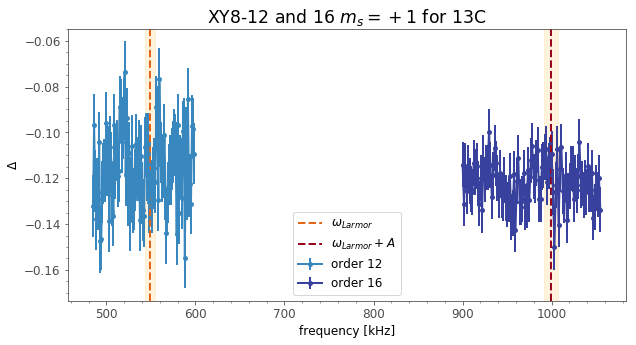

In [2594]:
fig, ax = plt.subplots(figsize=(10, 5))

#ax.errorbar(f2, delta2, yerr= std_delta2, marker='o', color="#3887BE", linestyle='-', label=r'$m_s = +1$')
ax.errorbar(f2, delta2, yerr= std_delta2, marker='o', color="#3887BE", linestyle='-', label='order 12')
ax.axvline(x=peak_res, color='#E36414', linestyle='--', label=r'$\omega_{Larmor}$')
ax.axvspan(peak_res - linewidth_res, peak_res + linewidth_res, alpha=0.2, color='#FFC55A')

#ax.errorbar(f3, delta3, yerr= std_delta3, marker='o', color="#38419D", linestyle='-', label=r'$m_s = +1$')
ax.errorbar(f3, delta3, yerr= std_delta3, marker='o', color="#38419D", linestyle='-', label='order 16')
ax.axvline(x=peak_right, color='#9A031E', linestyle='--', label=r'$\omega_{Larmor}+A$')
ax.axvspan(peak_right - linewidth_right, peak_right + linewidth_right, alpha=0.2, color='#FFC55A')

ax.legend()
ax.set_xlabel('frequency [kHz]')
ax.set_ylabel(r'$\Delta$')
ax.set_title(r'XY8-12 and 16 $m_s=+1$ for 13C')

plt.show()

plot_title = ax.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-16 C +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

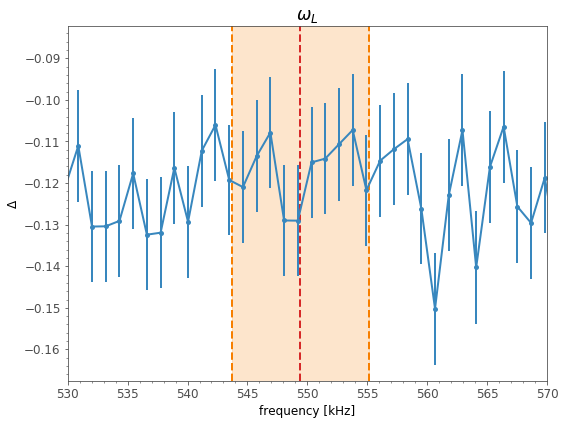

In [2600]:
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.errorbar(f2, delta3, yerr=std_delta2, marker='o', color='#3887BE', linestyle='-', label=r'$m_s = +1$')
ax2.axvline(x=peak_res, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}$')
ax2.axvline(x=peak_res + linewidth_res, color='#F77F00', linestyle='--')
ax2.axvline(x=peak_res - linewidth_res, color='#F77F00', linestyle='--')
ax2.axvspan(peak_res - linewidth_res, peak_res + linewidth_res, alpha=0.2, color='#F77F00')
ax2.set_xlabel(r'frequency [kHz]')
ax2.set_ylabel(r'$\Delta$')
ax2.set_title(r'$\omega_L$')

ax2.set_xlim(530, 570)

#ax2.legend()
fig.tight_layout()
plt.show()

plot_title = ax2.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-16 C +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

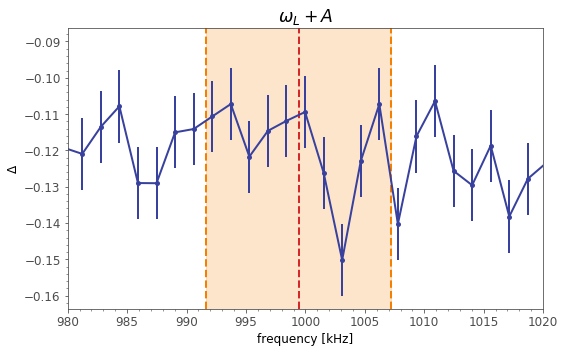

In [2606]:
fig, ax3 = plt.subplots(figsize=(8, 5))
ax3.errorbar(f3, delta3, yerr=std_delta3, marker='o', color='#38419D', linestyle='-', label=r'$m_s = +1$')
ax3.axvline(x=peak_right, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}+A$')
ax3.axvline(x=peak_right + linewidth_right, color='#F77F00', linestyle='--')
ax3.axvline(x=peak_right - linewidth_right, color='#F77F00', linestyle='--')
ax3.axvspan(peak_right - linewidth_right, peak_right + linewidth_right, alpha=0.2, color='#F77F00')
ax3.set_xlabel(r'frequency [kHz]')
ax3.set_ylabel(r'$\Delta$')
ax3.set_title(r'$\omega_L +A$')

ax3.set_xlim(980, 1020)

#ax3.legend()
fig.tight_layout()
plt.show()

plot_title = ax3.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-16 C +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

### plot 3 in same fig

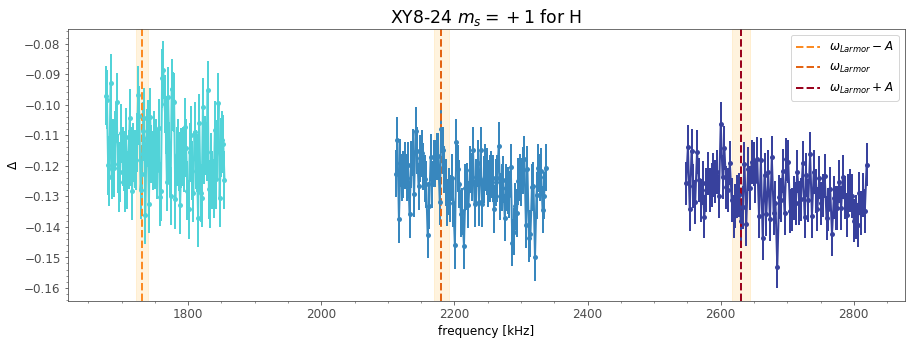

In [1652]:
fig, ax = plt.subplots(figsize=(15, 5))

#ax.errorbar(f1, delta1, yerr= std_delta1, marker='o', color="#52D3D8", linestyle='-', label=r'$m_s = +1$')
ax.errorbar(f1, delta1, yerr= std_delta1, marker='o', color="#52D3D8", linestyle='-')
ax.axvline(x=peak_left, color='#FB8B24', linestyle='--', label=r'$\omega_{Larmor}-A$')
ax.axvspan(peak_left - linewidth_left, peak_left + linewidth_left, alpha=0.2, color='#FFC55A')

#ax.errorbar(f2, delta2, yerr= std_delta2, marker='o', color="#3887BE", linestyle='-', label=r'$m_s = +1$')
ax.errorbar(f2, delta2, yerr= std_delta2, marker='o', color="#3887BE", linestyle='-')
ax.axvline(x=peak_res, color='#E36414', linestyle='--', label=r'$\omega_{Larmor}$')
ax.axvspan(peak_res - linewidth_res, peak_res + linewidth_res, alpha=0.2, color='#FFC55A')

#ax.errorbar(f3, delta3, yerr= std_delta3, marker='o', color="#38419D", linestyle='-', label=r'$m_s = +1$')
ax.errorbar(f3, delta3, yerr= std_delta3, marker='o', color="#38419D", linestyle='-')
ax.axvline(x=peak_right, color='#9A031E', linestyle='--', label=r'$\omega_{Larmor}+A$')
ax.axvspan(peak_right - linewidth_right, peak_right + linewidth_right, alpha=0.2, color='#FFC55A')

ax.legend()
ax.set_xlabel('frequency [kHz]')
ax.set_ylabel(r'$\Delta$')
ax.set_title(r'XY8-24 $m_s=+1$ for H')

plt.show()

plot_title = ax.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-24 H +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

### plot singles

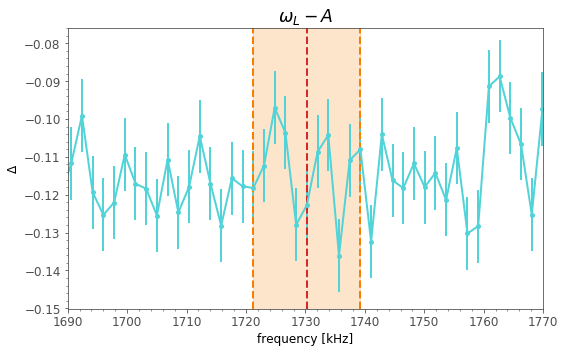

In [1658]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.errorbar(f1, delta1, yerr=std_delta1, marker='o', color='#52D3D8', linestyle='-', label=r'$m_s = +1$')
ax1.axvline(x=peak_left, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}-A$')
ax1.axvline(x=peak_left + linewidth_left, color='#F77F00', linestyle='--')
ax1.axvline(x=peak_left - linewidth_left, color='#F77F00', linestyle='--')
ax1.axvspan(peak_left - linewidth_left, peak_left + linewidth_left, alpha=0.2, color='#F77F00')
ax1.set_xlabel(r'frequency [kHz]')
ax1.set_ylabel(r'$\Delta$')
ax1.set_title(r'$\omega_L -A$')

ax1.set_xlim(1690, 1770)

#ax1.legend()
fig.tight_layout()
plt.show()

plot_title = ax1.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-24 H +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

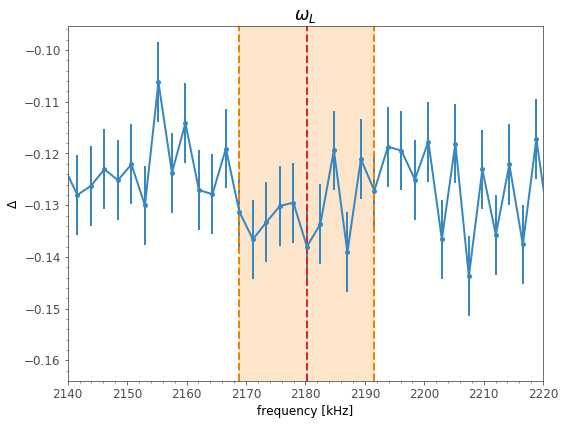

In [1664]:
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.errorbar(f2, delta3, yerr=std_delta2, marker='o', color='#3887BE', linestyle='-', label=r'$m_s = +1$')
ax2.axvline(x=peak_res, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}$')
ax2.axvline(x=peak_res + linewidth_res, color='#F77F00', linestyle='--')
ax2.axvline(x=peak_res - linewidth_res, color='#F77F00', linestyle='--')
ax2.axvspan(peak_res - linewidth_res, peak_res + linewidth_res, alpha=0.2, color='#F77F00')
ax2.set_xlabel(r'frequency [kHz]')
ax2.set_ylabel(r'$\Delta$')
ax2.set_title(r'$\omega_L$')

ax2.set_xlim(2140, 2220)

#ax2.legend()
fig.tight_layout()
plt.show()

plot_title = ax2.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-24 H +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

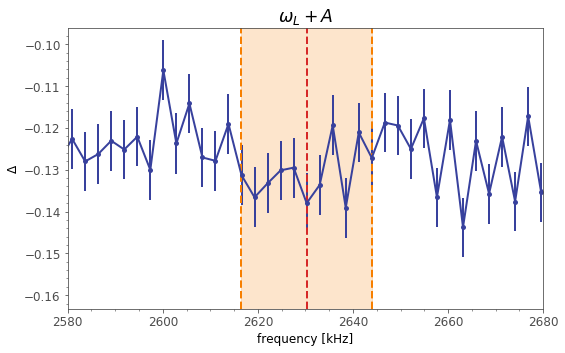

In [1670]:
fig, ax3 = plt.subplots(figsize=(8, 5))
ax3.errorbar(f3, delta3, yerr=std_delta3, marker='o', color='#38419D', linestyle='-', label=r'$m_s = +1$')
ax3.axvline(x=peak_right, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}+A$')
ax3.axvline(x=peak_right + linewidth_right, color='#F77F00', linestyle='--')
ax3.axvline(x=peak_right - linewidth_right, color='#F77F00', linestyle='--')
ax3.axvspan(peak_right - linewidth_right, peak_right + linewidth_right, alpha=0.2, color='#F77F00')
ax3.set_xlabel(r'frequency [kHz]')
ax3.set_ylabel(r'$\Delta$')
ax3.set_title(r'$\omega_L +A$')

ax3.set_xlim(2580, 2680)

#ax3.legend()
fig.tight_layout()
plt.show()

plot_title = ax3.get_title()
plot_filename = ''.join(char if char.isalnum() or char in ['+', '-'] else '_' for char in plot_title)
full_path = r'E:\Data\2024\05\The Hunt\plots\XY8-24 H +1\{}.png'.format(plot_filename)
fig.savefig(full_path, dpi=300, bbox_inches='tight')

### plot 3 in different figures

In [ ]:
f4 = f1[:]
delta4 = delta1[::-1]
std_delta4 = std_delta1[::-1]

f5 = f2[:]
delta5 = delta2[::-1]
std_delta5 = std_delta2[::-1]

f6 = f3[:]
delta6 = delta3[::-1]
std_delta6 = std_delta3[::-1]

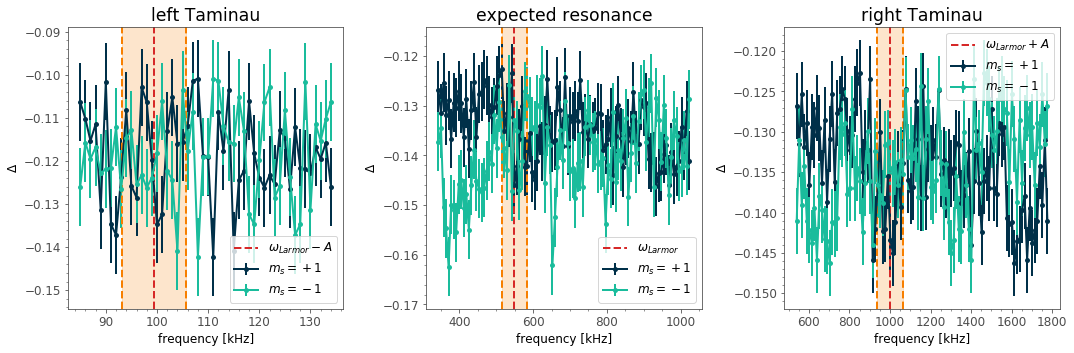

In [130]:
#fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(15, 5), sharey = 'row')
fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(15, 5))

# Plot for left Taminau
ax1.errorbar(f1, delta1, yerr= std_delta1, marker='o', color='#003049', linestyle='-', label=r'$m_s = +1$')
ax1.errorbar(f4, delta4, yerr=std_delta4, marker='o', color='#1ABC9C', linestyle='-', label=r'$m_s = -1$')

ax1.axvline(x=peak_left, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}-A$')
ax1.axvline(x=peak_left + linewidth_left, color='#F77F00', linestyle='--')
ax1.axvline(x=peak_left - linewidth_left, color='#F77F00', linestyle='--')
ax1.axvspan(peak_left - linewidth_left, peak_left + linewidth_left, alpha=0.2, color='#F77F00')
ax1.set_xlabel(r'frequency [kHz]')
ax1.set_ylabel(r'$\Delta$')
ax1.set_title('left Taminau')
ax1.legend()

# plot resonance freq
ax2.errorbar(f2, delta3, yerr=std_delta2, marker='o', color='#003049', linestyle='-', label=r'$m_s = +1$')
ax2.errorbar(f5, delta5, yerr=std_delta5, marker='o', color='#1ABC9C', linestyle='-', label=r'$m_s = -1$')

ax2.axvline(x=peak_res, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}$')
ax2.axvline(x=peak_res + linewidth_res, color='#F77F00', linestyle='--')
ax2.axvline(x=peak_res - linewidth_res, color='#F77F00', linestyle='--')
ax2.axvspan(peak_res - linewidth_res, peak_res + linewidth_res, alpha=0.2, color='#F77F00')
ax2.set_xlabel(r'frequency [kHz]')
ax2.set_ylabel(r'$\Delta$')
ax2.set_title('expected resonance')
ax2.legend()

# Plot for right Taminau
ax3.errorbar(f3, delta3, yerr=std_delta3, marker='o', color='#003049', linestyle='-', label=r'$m_s = +1$')
ax3.errorbar(f6, delta6, yerr=std_delta6, marker='o', color='#1ABC9C', linestyle='-', label=r'$m_s = -1$')

ax3.axvline(x=peak_right, color='#D62828', linestyle='--', label=r'$\omega_{Larmor}+A$')
ax3.axvline(x=peak_right + linewidth_right, color='#F77F00', linestyle='--')
ax3.axvline(x=peak_right - linewidth_right, color='#F77F00', linestyle='--')
ax3.axvspan(peak_right - linewidth_right, peak_right + linewidth_right, alpha=0.2, color='#F77F00')
ax3.set_xlabel(r'frequency [kHz]')
ax3.set_ylabel(r'$\Delta$')
ax3.set_title('right Taminau')
ax3.legend()

fig.tight_layout()
plt.show()

# Ramsey study

In [14]:
fname = r"E:\Data\2024\05\data Ramsey\data_ramsey.csv"
data = pd.read_csv(fname)

data.columns

Index(['taus', '0', '0.01', '0.05', '0.1', '0.2', '0.3', '0.5', '0.9', '1',
       '10'],
      dtype='object')

In [17]:
tau = np.asarray(data['taus'])
A0 = np.asarray(data['0'])
A001 =  np.asarray(data['0.01'])
A005 = np.asarray(data['0.05'])
A01 = np.asarray(data['0.1'])
A02 = np.asarray(data['0.2'])
A03 = np.asarray(data['0.3'])
A05 = np.asarray(data['0.5'])
A09 = np.asarray(data['0.9'])
A1 = np.asarray(data['1'])
A10 = np.asarray(data['10'])

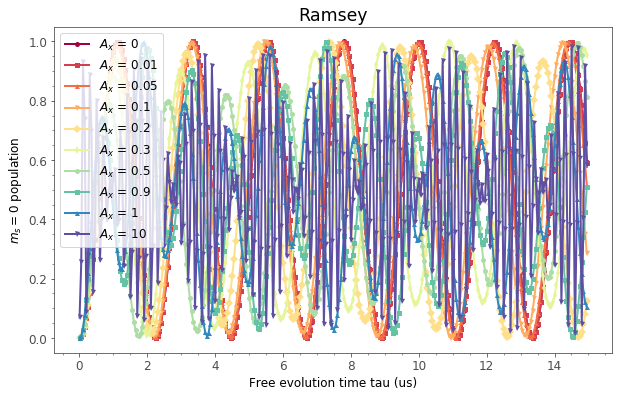

In [266]:
palette = ['#9e0142', '#d53e4f', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#abdda4', '#66c2a5', '#3288bd', '#5e4fa2']
plt.figure(figsize=(10, 6))
for i in range(len(data.columns)-1):
    plt.plot(tau, data.iloc[:,i+1], label=f'$A_x$ = {data.columns[i+1]}', color=palette[i])

plt.title('Ramsey')
plt.xlabel('Free evolution time tau (us)')
plt.ylabel(r'$m_s=0$ population')
plt.legend()
plt.show()

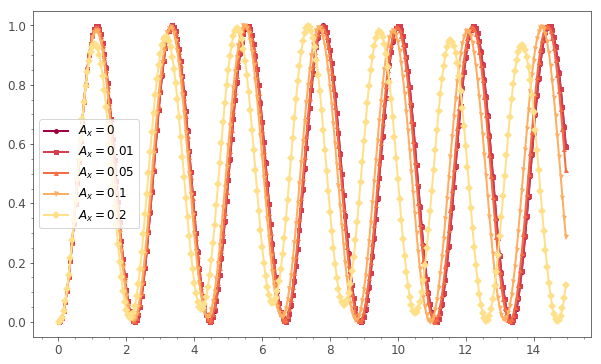

In [275]:
palette = ['#9e0142', '#d53e4f', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#abdda4', '#66c2a5', '#3288bd', '#5e4fa2']
plt.figure(figsize=(10, 6))
plt.plot(tau, A0, label=r'$A_x = 0$', color=palette[0])
plt.plot(tau, A001, label=r'$A_x = 0.01$', color=palette[1])
plt.plot(tau, A005, label=r'$A_x = 0.05$', color=palette[2])
plt.plot(tau, A01, label=r'$A_x = 0.1$', color=palette[3])
plt.plot(tau, A02, label=r'$A_x = 0.2$', color=palette[4])
#plt.plot(tau, A03, label=r'$A_x = 0.3$', color=palette[5])
#plt.plot(tau, A05, label=r'$A_x = 0.5$', color=palette[6])
#plt.plot(tau, A09, label=r'$A_x = 0.9$', color=palette[7])
#plt.plot(tau, A1, label=r'$A_x = 1$', color=palette[8])
#plt.plot(tau, A10, label=r'$A_x = 10$', color=palette[9])
plt.legend()
plt.show()

## FFTs

In [48]:
try:
    fft_x1, fft_1 = compute_ft(x_val=tau, y_val=A0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=0)

    fft_x2, fft_2 = compute_ft(x_val=tau, y_val=A001)
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=1)

    fft_x3, fft_3 = compute_ft(x_val=tau, y_val=A005)
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=2)
    
    fft_x4, fft_4 = compute_ft(x_val=tau, y_val=A01)
    qdplotlogic.set_data(fft_x4, fft_4, plot_index=3)

    fft_x5, fft_5 = compute_ft(x_val=tau, y_val=A02)
    qdplotlogic.set_data(fft_x5, fft_5, plot_index=4)

    fft_x6, fft_6 = compute_ft(x_val=tau, y_val=A03)
    qdplotlogic.set_data(fft_x6, fft_6, plot_index=5)
    
    fft_x7, fft_7 = compute_ft(x_val=tau, y_val=A05)
    qdplotlogic.set_data(fft_x7, fft_7, plot_index=6)
    
    fft_x8, fft_8 = compute_ft(x_val=tau, y_val=A09)
    qdplotlogic.set_data(fft_x8, fft_8, plot_index=7)

    fft_x9, fft_9 = compute_ft(x_val=tau, y_val=A1)
    qdplotlogic.set_data(fft_x9, fft_9, plot_index=8)

    fft_x0, fft_0 = compute_ft(x_val=tau, y_val=A10)
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=9)
except:
    logger.exception("")

## sin fit

In [54]:
def do_fit(p_mes, fit_y='delta', fit_method='sine', edit_params=None, settings=None):
    fitter = pulsedmeasurementlogic.fc   
    
    if edit_params:
        for ov_param in edit_params:
            
            if ov_param.name in fitter.fit_list[fit_method]['parameters'].keys():
                fitter.fit_list[fit_method]['use_settings'][ov_param.name] = True
                fitter.fit_list[fit_method]['parameters'][ov_param.name] = ov_param
                
                #logger.debug(f"Overwriting fit param {ov_param.name}: {ov_param}")

    fitter.clear_result()
    fitter.set_current_fit(fit_method)
    """
    x_fit, y_fit, result = fitter.do_fit(data[0], data[1])
    result = result.result_str_dict

    """

    if fit_y == 'delta':
        data = np.asarray(p_mes['data']['tau']), np.asarray(delta_or_z1(p_mes))
    elif fit_y == 'z1':
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data']['z1'])
    elif fit_y == 'z2':
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data']['z2'])
    else:
        data = np.asarray(p_mes['data']['tau']), np.asarray(p_mes['data'][fit_y])
        
    
    slice_idx = slice(0, None)
    if settings:
        if 'slice_data' in settings.keys():
            slice_idx = settings['slice_data']
            
    x_fit, y_fit, result = fitter.do_fit(data[0][slice_idx], data[1][slice_idx])
    # params [lmfit::Parameters] and derived params [dict]
    # considered in _get_fit()
    
    # get values of fitted model
    model = fitter.fit_list[fit_method]['make_model']()[0]
    
    x_domain = np.asarray(p_mes['data']['tau'])
    x_domain = np.linspace(np.min(x_domain), np.max(x_domain), 1000)
    if settings:
        if 'fit_range' in settings.keys():
            x_domain = settings['fit_range']

    y = model.eval(x=x_domain, params=result.params)
    fit_vals = {'x': x_domain, 
                'y': y}
    
    full_result = {**result.params, **result.result_str_dict}
    p_mes['fit_res'] = full_result
    p_mes['fit_values'] = fit_vals
    
    reset_fitter(fit_method, edit_params)
    
0

0

In [57]:
pulsedmeasurementlogic.fc

In [63]:
p_mes = {}
p_mes['data'] = {'tau': tau, 'z1': A09}
0

0

In [66]:
try:
    do_fit(p_mes, fit_y='z1', fit_method='sine_2x', edit_params=None, settings=None)
except:
    logger.exception("")

In [72]:
try:
    x_fit, y_fit = p_mes['fit_values']['x'],  p_mes['fit_values']['y']

    plt.plot(tau, A09, label="sim")
    plt.plot(x_fit, y_fit, label="fit")

    plt.legend()
    plt.show()
except:
    logger.exception("")

# Simulated Ramsey with detuning

In [338]:
fname = r"E:\Data\2024\06\simulated_ramsey_detuning" + "\\" + "Ramsey_det_3.csv"
p_data = pd.read_csv(fname)

p_data.columns

Index(['taus', 'data'], dtype='object')

In [341]:
tau = p_data['taus'].values
signal = p_data['data'].values

try:
    fft_tau, fft_signal = compute_ft(x_val=tau, y_val=signal)
    qdplotlogic.set_data(fft_tau, fft_signal, plot_index=0)
except:
    logger.exception("")
0

0

In [1898]:
fname = r"E:\Data\2024\06\new_detunings" + "\\" + "detuninigs_Azx_0.5_highH.csv"
p_data = pd.read_csv(fname)

tau = p_data['taus'].values
signal0 = p_data['4'].values
signal1 = p_data['3.6'].values
signal2 = p_data['3.8'].values

fft_x0, fft_0 = compute_ft(x_val=tau, y_val=signal0)
qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)

fft_x1, fft_1 = compute_ft(x_val=tau, y_val=signal1)
qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)

fft_x2, fft_2 = compute_ft(x_val=tau, y_val=signal2)
qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)

p_data.columns

Index(['taus', '2.1', '2.2', '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9',
       '3', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9',
       '4'],
      dtype='object')

In [1868]:
try:
    qdplotlogic.set_data(tau, signal0, plot_index=0)
    qdplotlogic.set_data(tau, signal1, plot_index=1)
    qdplotlogic.set_data(tau, signal2, plot_index=2)
except:
    logger.exception("")

In [1403]:
fft_x0, fft_0 = compute_ft(x_val=tau, y_val=signal0)
qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)

fft_x1, fft_1 = compute_ft(x_val=tau, y_val=signal1)
qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)

fft_x2, fft_2 = compute_ft(x_val=tau, y_val=signal2)
qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)

0

In [1322]:
# CARBON
deltas_Azx0 = [2000, 1884.0, 1803.1, 1715.7, 1600.0, 1484.0, 1404.3, 1315.8, 1200.0, 1083.0,
               1006.3, 916.0, 800.0, 683.5, 610.3, 516.3, 400.43, 287.2, 244.0, 130.0,
               130.0, 244.0, 287.2, 400.0, 516.3, 610.3, 683.5, 800.0, 916.0 ] #last is 0.9

#missing 0.2 bc of fit ucks up
deltas_Azx900 = [2137.0, 2055.0, 1982.2, 1867.0, 1766.6, 1706.2, 1600.0, 1491.1, 1435.0, 1333.0
                 1227.0, 1175.0, 1066.0, 985.9, 925.0, 815.0, 778.0, 668.0, 642.0, 540.0
                 458.0, 0, 399.0, 382.0]


# HYDROGREN
deltas_Azx500 = [2014.0, 1929.9, 1847.6, 1733.0, 1616.0, 1538.1, 1450.0, 1333.0, 1220.4, 1148.1,
                 1052.3, 933.0, 827.2, 760.1, 657.9, 533.0, 442.4, 378.0, 263.0, 138.0,
                 64.0, 140.0, 251.2, 347.0, 409.6, 532.0, 639.3, 701.1, 800.0, 915.3, 985.7,
                 1067.0, 1183.0, 1245.4, 1333.0, 1432.0, 1470.0, 1572.0, 1600.0, 1635.0]
deltas_Azx900 = [2112.4, 2000.0, 1884.0, 1809.2, 1719.2, 1600.0, 1496.4, 1430.5, 1331.0, 1204.0,
                 1120.7, 1046.3, 933.0, 821.3, 758.1, 660.45, 534.0, 461.7, 383.1, 267.23,
                 149.0, 0, 130.0, 197.0, 267.0, 383.0, 443.3, 533.0, 637.0, 679.0, 788.0,
                 841.0, 932.0, 986.0, 1065.0, 1096.0, 1179.0, 1200.0, 1223.0, 1267.0]
deltas_Azx0 = [2000.0, 1884.0, 1803.1, 1715.7, 1600.0, 1484.0, 1404.3, 1315.8, 1200.0, 1083.0,
               1006.3, 916.0, 800.0, 683.5, 610.3, 516.3, 400.43, 287.2, 244.0, 130.0,
               130.0, 244.0, 287.2, 400.43, 516.3, 610.3, 683.5, 800.0, 916.0, 1006.3,
               1083.0, 1200.0, 1315.8, 1404.3, 1484.0, 1600.0, 1715.7, 1803.1, 1884.0, 2000.0]

#highH
Azz = [2.2, 2.4, 2.6, 2.8, 3, 3.2, 3.4, 3.6, 3.8, 4]
highH_100 = [2222.3, 2406.0, 2624.8, 2800.0, 3013.8, 3200.0, 3409.2, 3600.0, 3806.7, 4000]
highH_900 = [1301.0, 3100.0, 3192.0, 3284.0, 3399.0, 3550.0, 3713.0, 3866.6, 4018.0, 4221.4]
highH_500 = [1705.0, 2729.0, 2820.0, 2963.0, 3150.2, 3331.0, 3483, 3701, 3867, 4068.5]

In [1022]:
qdplotlogic.get_fit_data(plot_index=0)

(array([[[ 0.00000000e+00,  6.62663998e-03,  1.32532800e-02, ...,
          9.92008005e+00,  9.92670669e+00,  9.93333333e+00],
        [-1.90960838e-03, -1.90945392e-03, -1.90929850e-03, ...,
         -1.93255999e-03, -1.93259890e-03, -1.93263766e-03]]]), 'data_set 0:\n  Position 0: 3000.0 ± 5.0 m \n  Position 1: 5000.0 ± 5.0 m \n  Splitting: 2000.0 ± 10.0 m \n  Contrast 0: 12.0 ± 4.0 k% \n  Contrast 1: 12.0 ± 4.0 k% \n  FWHM 0: 67.0 ± 5.0 m \n  FWHM 1: 67.0 ± 5.0 m \n  chi_sqr: 9.7018 m\n', 'lorentz_peak_2x')

## pairs of 900kHz delta

In [1808]:
H_fname = r"E:\Data\2024\06\new_detunings" + "\\" + "H_pairs_delta900.csv"
C_fname = r"E:\Data\2024\06\new_detunings" + "\\" + "C_pairs_delta900.csv"

p_data = pd.read_csv(H_fname)

p_data.shape[1]

# Hydrogen: 770 cols, first is taus, then from circa 0.9 to circa 3.5 // w_l 2.18 approx 385
# Carbon: 581 cols, first is taus, value from circa -1 to circa 2 // w_l = 0.55 approx 419

# how to access columns:
# p_data.iloc[:, n] : n-th col
# p_data.iloc[:, :n] : all cols up to n
# p_data.iloc[:, m:n] : cols from m to n


838

In [1847]:
tau = p_data['taus'].values

signal0 = p_data.iloc[:, 750]
signal1 = p_data.iloc[:, 800]
signal2 = p_data.iloc[:, 837]
0

0

In [1850]:
fft_x0, fft_0 = compute_ft(x_val=tau, y_val=signal0)
qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)

fft_x1, fft_1 = compute_ft(x_val=tau, y_val=signal1)
qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)

fft_x2, fft_2 = compute_ft(x_val=tau, y_val=signal2)
qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)

0

# Double sine fit on ramseys

In [353]:
fname = r"E:\Data\2024\06\delta_frequency\fixed_Azx" + "\\" + "deltaF_Azx_0.9.csv"
p_data = pd.read_csv(fname)

p_data.columns

Index(['taus', '-2', '-1.9', '-1.8', '-1.7', '-1.6', '-1.5', '-1.4', '-1.3',
       '-1.2', '-1.1', '-1', '-0.9', '-0.8', '-0.7', '-0.6', '-0.5', '-0.4',
       '-0.3', '-0.2', '-0.1', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7',
       '0.8', '0.9', '1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7',
       '1.8', '1.9', '2'],
      dtype='object')

In [371]:
tau = p_data['taus'].values
signal0 = p_data['-2'].values
signal1 = p_data['-1.9'].values
signal2 = p_data['-1.8'].values
signal3 = p_data['-1.7'].values
signal4 = p_data['-1.6'].values
signal5 = p_data['-1.5'].values
signal6 = p_data['-1.4'].values
signal7 = p_data['-1.3'].values
signal8 = p_data['-1.2'].values
signal9 = p_data['-1.1'].values
signal10 = p_data['-1'].values
signal11 = p_data['-0.9'].values
signal12 = p_data['-0.8'].values
signal13 = p_data['-0.7'].values
signal14 = p_data['-0.6'].values
signal15 = p_data['-0.5'].values
signal16 = p_data['-0.4'].values
signal17 = p_data['-0.3'].values
signal18 = p_data['-0.2'].values
signal19 = p_data['-0.1'].values
signal20 = p_data['0.1'].values
signal21 = p_data['0.2'].values
signal22 = p_data['0.3'].values
signal23 = p_data['0.4'].values
signal24 = p_data['0.5'].values
signal25 = p_data['0.6'].values
signal26 = p_data['0.7'].values
signal27 = p_data['0.8'].values
signal28 = p_data['0.9'].values
signal29 = p_data['1'].values
signal30 = p_data['1.1'].values
signal31 = p_data['1.2'].values
signal32 = p_data['1.3'].values
signal33 = p_data['1.4'].values
signal34 = p_data['1.5'].values
signal35 = p_data['1.6'].values
signal36 = p_data['1.7'].values
signal37 = p_data['1.8'].values
signal38 = p_data['1.9'].values
signal39 = p_data['2'].values

In [401]:
try:
    qdplotlogic.set_data(tau, signal17, plot_index=0)
    qdplotlogic.set_data(tau, signal30, plot_index=1)
    qdplotlogic.set_data(tau, signal15, plot_index=2)
    #qdplotlogic.set_data(tau, signal3, plot_index=3)
    #qdplotlogic.set_data(tau, signal4, plot_index=4)
    #qdplotlogic.set_data(tau, signal5, plot_index=5)
except:
    logger.exception("")

In [398]:
fft_x0, fft_0 = compute_ft(x_val=tau, y_val=signal17)
qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)

fft_x1, fft_1 = compute_ft(x_val=tau, y_val=signal30)
qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)

fft_x2, fft_2 = compute_ft(x_val=tau, y_val=signal15)
qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)

0

# Ramsey FFTs

In [1901]:
start =  905.100703125
now = 908.32265625

## detuning comparison

In [69]:
try:
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240621-1357-16_Ramsey_det_0.0MHz_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240621-1557-57_Ramsey_det_0.1MHz_pulsed_measurement.dat"
    p_data100 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240621-1758-37_Ramsey_det_0.2MHz_pulsed_measurement.dat"
    p_data200 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240621-1959-16_Ramsey_det_0.5MHz_pulsed_measurement.dat"
    p_data500 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240621-2159-57_Ramsey_det_1.0MHz_pulsed_measurement.dat"
    p_data1 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240622-0000-36_Ramsey_det_2.0MHz_pulsed_measurement.dat"
    p_data2 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240622-0201-16_Ramsey_det_5.0MHz_pulsed_measurement.dat"
    p_data5 = Tk_file.load_pulsed_result(fname)
except:
    logger.exception("")

In [72]:
try:
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data100['data']['tau']), y_val=get_z(p_data100, 'delta'))
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data200['data']['tau']), y_val=get_z(p_data200, 'delta'))
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data500['data']['tau']), y_val=get_z(p_data500, 'delta'))
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
    fft_x4, fft_4 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    qdplotlogic.set_data(fft_x4, fft_4, plot_index=4)
    fft_x5, fft_5 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    qdplotlogic.set_data(fft_x5, fft_5, plot_index=5)
    fft_x6, fft_6 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    qdplotlogic.set_data(fft_x6, fft_6, plot_index=6)
except:
    logger.exception("")

## delta F

In [102]:
#ms = +1, no detuning
try:
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240620-1100-27_ramsey_phi-1_ms+1_pulsed_measurement.dat"
    p_data_m1 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240620-1232-21_ramsey_phi-0.5_ms+1_pulsed_measurement.dat"
    p_data_m05 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240620-1319-22_ramsey_phi+0.5_ms+1_pulsed_measurement.dat"
    p_data_p05 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240620-1611-47_ramsey_phi+1_ms+1_pulsed_measurement.dat"
    p_data_p1 = Tk_file.load_pulsed_result(fname)
    
    #+2 and -2 could be done again with more meas time
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240620-2221-25_ramsey_phi+2_ms+1_pulsed_measurement.dat"
    p_data2 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms+1" + "\\" + "20240621-0605-26_ramsey_phi-2_ms+1_pulsed_measurement.dat"
    p_data5 = Tk_file.load_pulsed_result(fname)
except:
    logger.exception("")
0

0

In [105]:
try:
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data_m1['data']['tau']), y_val=get_z(p_data_m1, 'delta'))
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data_m05['data']['tau']), y_val=get_z(p_data_m05, 'delta'))
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data_p05['data']['tau']), y_val=get_z(p_data_p05, 'delta'))
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data_p1['data']['tau']), y_val=get_z(p_data_p1, 'delta'))
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
    
except:
    logger.exception("")

In [108]:
#ms = -1, 1 MHz det
try:
    #fname = r"E:\Data\2024\06\ramsey_tiltedB\ms-1" + "\\" + ""
    #p_data_m1 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms-1" + "\\" + "20240624-0944-01_ramsey_phi-0.5_ms-1_det1_pulsed_measurement.dat"
    p_data_m05 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms-1" + "\\" + "20240623-1601-35_ramsey_phi+0.5_ms-1_det1_pulsed_measurement.dat"
    p_data_p05 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\06\ramsey_tiltedB\ms-1" + "\\" + "20240624-0615-13_ramsey_phi+1.5_ms-1_det1_pulsed_measurement.dat"
    p_data_p15 = Tk_file.load_pulsed_result(fname)
    
except:
    logger.exception("")
0

0

In [111]:
fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data_p15['data']['tau']), y_val=get_z(p_data_p15, 'delta'))
qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data_m05['data']['tau']), y_val=get_z(p_data_m05, 'delta'))
qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data_p05['data']['tau']), y_val=get_z(p_data_p05, 'delta'))
qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)

0

# DEERs

In [42]:
## compute B from pODMR
line = 1273.4e6
ZFS = 2870e6
B = (ZFS - line)/2.8
B, ZFS-line

(570214285.7142857, 1596600000.0)

In [95]:
## p1 line from
B = 82 # Gauss
ZFS = 2870e6
nvline = ZFS - 2.8*B*10**6
p1line = 2.8*B*10**6
p1line

229600000.0

## first study

In [227]:
# deer rabi
fname = r"E:\Data\2024\07\20240708\PulsedMeasurement" + "\\" + "20240708-1053-20_deer_rabi_pulsed_measurement.dat"
fname = r"E:\Data\2024\07\20240708\PulsedMeasurement" + "\\" + "20240708-1353-12_deer_rabi_pulsed_measurement.dat"

p_data = Tk_file.load_pulsed_result(fname)

delta, delta_std = get_z(p_data, 'delta')
tau = p_data['data']['tau']
z1 = p_data['data']['z1']
z2 = p_data['data']['z2']

qdplotlogic.set_data(tau, delta, plot_index=0)
qdplotlogic.set_data(tau, z1, plot_index=1)
qdplotlogic.set_data(tau, z2, plot_index=2)

0

In [62]:
# time deer
fname0 = r"E:\Data\2024\07\DEER_time_sweep" + "\\" + "20240709-0403-51_DEER_B540_hetau_10.0_sweep_pfac_2_pulsed_measurement.dat"
fname1 = r"E:\Data\2024\07\DEER_time_sweep" + "\\" + "20240709-0604-47_DEER_B540_hetau_15.0_sweep_pfac_2_pulsed_measurement.dat"
fname2 = r"E:\Data\2024\07\DEER_time_sweep" + "\\" + "20240709-0805-57_DEER_B540_hetau_20.0_sweep_pfac_2_pulsed_measurement.dat"
fname3 = r"E:\Data\2024\07\DEER_time_sweep" + "\\" + "20240709-1007-20_DEER_B540_hetau_25.0_sweep_pfac_2_pulsed_measurement.dat"
#beore calibration
#fname3 = r"E:\Data\2024\07\DEER_time_sweep\pre DEER rabi" + "\\" + "20240705-1352-02_DEER_B540_hetau10us_pfac2_pulsed_measurement.dat"

p_data0 = Tk_file.load_pulsed_result(fname0)
p_data1 = Tk_file.load_pulsed_result(fname1)
p_data2 = Tk_file.load_pulsed_result(fname2)
p_data3 = Tk_file.load_pulsed_result(fname3)

delta0, delta_std0 = get_z(p_data0, 'delta')
tau0 = p_data0['data']['tau']
delta1, delta_std1 = get_z(p_data1, 'delta')
tau1 = p_data1['data']['tau']
delta2, delta_std2 = get_z(p_data2, 'delta')
tau2 = p_data2['data']['tau']
delta3, delta_std3 = get_z(p_data3, 'delta')
tau3 = p_data3['data']['tau']

qdplotlogic.set_data(tau0, delta0, plot_index=0)
qdplotlogic.set_data(tau1, delta1, plot_index=1)
qdplotlogic.set_data(tau2, delta2, plot_index=2)
qdplotlogic.set_data(tau3, delta3, plot_index=3)

0

In [218]:
# deer spectrum with wrong dark pi length
fname0 = r"E:\Data\2024\07\DEER_sweep" + "\\" + "20240703-1007-10_DEER_B540_3_pulsed_measurement.dat"
fname1 = r"E:\Data\2024\07\20240709\PulsedMeasurement" + "\\" + "20240709-0102-16_DEER_B540_fcenter_1.5_pulsed_measurement.dat"

p_data0 = Tk_file.load_pulsed_result(fname0)
p_data1 = Tk_file.load_pulsed_result(fname1)

delta0, delta_std0 = get_z(p_data0, 'delta')
tau0 = p_data0['data']['tau']
delta1, delta_std1 = get_z(p_data1, 'delta')
tau1 = p_data1['data']['tau']

qdplotlogic.set_data(tau0, delta0, plot_index=0)
qdplotlogic.set_data(tau1, delta1, plot_index=1)

0

In [53]:
# deer spectrum with new dark pi legth
fname0 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240710-2227-11_DEER_newpidark_hetau_0.28200000000000003us_pulsed_measurement.dat"
fname1 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240711-0027-41_DEER_newpidark_hetau_0.565us_pulsed_measurement.dat"
fname2 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240711-0228-19_DEER_newpidark_hetau_1.7us_pulsed_measurement.dat"
fname3 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240711-0429-03_DEER_newpidark_hetau_2.8us_pulsed_measurement.dat"
fname4 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240711-0629-56_DEER_newpidark_hetau_3.955us_pulsed_measurement.dat"
fname5 = r"E:\Data\2024\07\20240711\PulsedMeasurement" + "\\" + "20240711-0830-57_DEER_newpidark_hetau_5.0us_pulsed_measurement.dat"

p_data0 = Tk_file.load_pulsed_result(fname0)
p_data1 = Tk_file.load_pulsed_result(fname1)
p_data2 = Tk_file.load_pulsed_result(fname2)
p_data3 = Tk_file.load_pulsed_result(fname3)
p_data4 = Tk_file.load_pulsed_result(fname4)
p_data5 = Tk_file.load_pulsed_result(fname5)

delta0, delta_std0 = get_z(p_data0, 'delta')
tau0 = p_data0['data']['tau']
delta1, delta_std1 = get_z(p_data1, 'delta')
tau1 = p_data1['data']['tau']
delta2, delta_std2 = get_z(p_data2, 'delta')
tau2 = p_data2['data']['tau']
delta3, delta_std3 = get_z(p_data3, 'delta')
tau3 = p_data3['data']['tau']
delta4, delta_std4 = get_z(p_data4, 'delta')
tau4 = p_data4['data']['tau']
delta5, delta_std5 = get_z(p_data5, 'delta')
tau5 = p_data5['data']['tau']

qdplotlogic.set_data(tau0, delta0, plot_index=0)
qdplotlogic.set_data(tau1, delta1, plot_index=1)
qdplotlogic.set_data(tau2, delta2, plot_index=2)
qdplotlogic.set_data(tau3, delta3, plot_index=3)
qdplotlogic.set_data(tau4, delta4, plot_index=4)
qdplotlogic.set_data(tau5, delta5, plot_index=5)

0

## different lines for different B

In [59]:
# B 540
fname = r"E:\Data\2024\07\20240710\PulsedMeasurement" + "\\" + "20240710-1324-16_DEER_B540_fcenter_1.525_pulsed_measurement.dat"

p_data = Tk_file.load_pulsed_result(fname)
    
delta, delta_std = get_z(p_data, 'delta')
tau = p_data['data']['tau']
delta = delta[:-1]
tau = tau[:-1]

qdplotlogic.set_data(tau, delta, plot_index=0)

0

In [332]:
#B562 line fit
try:
    fname0 = r"E:\Data\2024\07\DEER_sweep" + "\\" + "20240702-1810-43_DEER_B560_4_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\DEER_sweep" + "\\" + "20240702-1826-08_DEER_B560_5_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=3)
    qdplotlogic.set_data(tau1, delta1, plot_index=4)
except:
    logger.exception("")
0

0

In [326]:
#B562 spectra with different he_tau
try:
    fname0 = r"E:\Data\2024\07\20240715\PulsedMeasurement" + "\\" + "20240715-1054-40_DEER_B562_hetau_200us_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240715\PulsedMeasurement" + "\\" + "20240715-1159-38_DEER_B562_hetau_0.5us_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240715\PulsedMeasurement" + "\\" + "20240715-1300-05_DEER_B562_hetau_1.0us_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\07\20240715\PulsedMeasurement" + "\\" + "20240715-1400-53_DEER_B562_hetau_5.0us_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2, delta_std2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3, delta_std3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
except:
    logger.exception("")
0

0

In [47]:
#B562 deer rabi
try:
    fname0 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1029-51_deer_rabi_B560_hetau_0.8999999999999999_power4_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1057-55_deer_rabi_B560_hetau_1.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-0949-14_deer_rabi_B560_hetau_0.7_power4_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1009-32_deer_rabi_B560_hetau_0.7999999999999999_power4_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2, delta_std2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3, delta_std3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
except:
    logger.exception("")
0

0

In [53]:
#B562 spectra after deer rabi
try:
    fname0 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1130-08_DEER_B560_pidark_170.0ns_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1150-29_DEER_B560_pidark_180.0ns_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1210-50_DEER_B560_pidark_190.0ns_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1231-11_DEER_B560_pidark_200.0ns_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2, delta_std2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3, delta_std3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
except:
    logger.exception("")
0

0

In [24]:
#B562 time deer -- names used B540 bc of error
try:
    fname0 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1444-43_DEER_B540_hetau_10.0_sweep_pfac_4_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1605-29_DEER_B540_hetau_10.0_sweep_pfac_4_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240716\PulsedMeasurement" + "\\" + "20240716-1744-07_DEER_B560_hetau_10.0_sweep_pfac_4_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
except:
    logger.exception("")
0

0

In [41]:
#B582 line fit
try:
    fname0 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-0951-19_DEER_B580_sweep_trials_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-1000-46_DEER_B580_sweep_trials_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [47]:
#B582 deer rabi
try:
    fname0 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-1749-28_deer_rabi_B580new_hetau_0.5_power2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-1849-48_deer_rabi_B580new_hetau_0.6_power2_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-1950-10_deer_rabi_B580new_hetau_0.7_power2_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-2050-31_deer_rabi_B580new_hetau_0.7999999999999999_power2_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-2150-53_deer_rabi_B580new_hetau_0.8999999999999999_power2_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2, delta_std2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3, delta_std3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4, delta_std4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    
except:
    logger.exception("")
0

0

In [50]:
# B582 time deer
try:
    fname0 = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-0221-45_DEER_B540_pipulse_164.9_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-0422-29_DEER_B540_pipulse_167.1_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-0623-13_DEER_B540_pipulse_171.1_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)

    delta0, delta_std0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2, delta_std2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
except:
    logger.exception("")
0

0

In [32]:
# B560 fit for dips 
try:
    fname0 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-0345-12_DEER_B560sweep_fcenter_1.5_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240717\PulsedMeasurement" + "\\" + "20240717-0745-50_DEER_B560sweep_fcenter_1.7_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [101]:
# B560 left dip
try:
    fname = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-1936-07_timeDEER_B560_right_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta, delta_std = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    """delta = delta[:-1]
    tau = tau[:-1]"""

    qdplotlogic.set_data(tau, delta, plot_index=2)
except:
    logger.exception("")

In [107]:
try:
    fname0 = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-1657-24_timeDEER_B560_right_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\07\20240718\PulsedMeasurement" + "\\" + "20240718-1521-32_timeDEER_B560_left_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1= get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']

    """delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]"""
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [90]:
# long deer rabi B560
try:
    fname0 = r"E:\Data\2024\08\20240805\PulsedMeasurement" + "\\" + "20240805-2019-29_deer_rabi_long_B560_hetau4e-06_pfac15_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240805\PulsedMeasurement" + "\\" + "20240805-2320-32_deer_rabi_long_B560_hetau1e-05_pfac15_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240805\PulsedMeasurement" + "\\" + "20240806-0221-10_deer_rabi_long_B560_hetau4e-06_pfac18_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240805\PulsedMeasurement" + "\\" + "20240806-0522-14_deer_rabi_long_B560_hetau1e-05_pfac18_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240806\PulsedMeasurement" + "\\" + "20240806-1002-14_deer_rabi_long_B560_hetau2e-05_pfac15_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\08\20240806\PulsedMeasurement" + "\\" + "20240806-1104-05_deer_rabi_long_B560_hetau2e-05_pfac18_pulsed_measurement.dat"
        
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2= get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
    
except:
    logger.exception("")
0

0

In [21]:
# B560 deer rabi maxpower
try:
    fname = r"E:\Data\2024\08\20240806\PulsedMeasurement" + "\\" + "20240806-1647-58_deer_rabi_B560_maxpower_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta, delta_std = get_z(p_data, 'delta')
    tau = p_data['data']['tau']

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")
0

In [54]:
#double dip
try:
    fname = r"E:\Data\2024\08\20240807\PulsedMeasurement" + "\\" + "20240807-2048-20_DEER_B560_pidark_4.5e-06_echo_1e-05_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1154-01_DEER_B560_doubledip_echo5e-06_pi4.4e-06_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1801-03_DEER_B560_doubledip_echo5e-06_pi4e-06_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1600-36_DEER_B560_doubledip_echo5e-06_pi4.2e-06_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname)
    p_data3 = Tk_file.load_pulsed_result(fname1)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta = delta[:-1]
    tau = tau[:-1]
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
 
    qdplotlogic.set_data(tau, delta, plot_index=1)
    qdplotlogic.set_data(tau1, delta1, plot_index=2)
    qdplotlogic.set_data(tau2, delta2, plot_index=3)
    qdplotlogic.set_data(tau3, delta3, plot_index=4)
except:
    logger.exception("")
0

0

In [105]:
#rabis on double dip
try:
    fname0 = r"E:\Data\2024\08\20240809\PulsedMeasurement" + "\\" + "20240809-1932-59_deer_rabi_B560_CENTER_hetau_10.0_pfac18_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240809\PulsedMeasurement" + "\\" + "20240809-1356-18_deer_rabi_B560_LEFT_hetau_10.0_pfac18_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240809\PulsedMeasurement" + "\\" + "20240809-1731-02_deer_rabi_B560_RIGHT_hetau_10.0_pfac18_pulsed_measurement.dat"
    #shorter total time
    #fname0 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" +
    #fname1 = r"E:\Data\2024\08\20240809\PulsedMeasurement" + "\\" + "20240809-1149-45_deer_rabi_B560_LEFT_hetau_4.0_pfac18_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\08\20240809\PulsedMeasurement" + "\\" + "20240809-1423-06_deer_rabi_B560_RIGHT_hetau_4.0_pfac18_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0) #center
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #left
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #right
except:
    logger.exception("")
0

0

In [23]:
# double dip spectrum - transition to one dip?
try:
    fname = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1154-01_DEER_B560_doubledip_echo5e-06_pi4.4e-06_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1600-36_DEER_B560_doubledip_echo5e-06_pi4.2e-06_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240810\PulsedMeasurement" + "\\" + "20240810-1801-03_DEER_B560_doubledip_echo5e-06_pi4e-06_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240812\PulsedMeasurement" + "\\" + "20240812-0956-20_DEER_B560_doubledip_echo5e-06_pi3.5e-06_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240812\PulsedMeasurement" + "\\" + "20240812-1040-06_DEER_B560_doubledip_echo5e-06_pi3.2e-06_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\08\20240812\PulsedMeasurement" + "\\" + "20240812-1115-10_DEER_B560_doubledip_echo5e-06_pi3e-06_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    delt = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta = delta[:-1]
    tau = tau[:-1]
    delta = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta4 = delta4[:-1]
    tau4 = tau4[:-1]
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
    delta5 = delta5[:-1]
    tau5 = tau5[:-1]
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

0

In [24]:
# low power rabi o factor = 35
try:
    fname = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-1402-34_deer_rabi_B560_RIGHT_hetau_10.0_pfac35_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-1444-11_deer_rabi_B560_RIGHT_hetau_7.0_pfac35_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-1510-04_deer_rabi_B560_RIGHT_hetau_7.6_pfac35_pulsed_measurement.dat"

    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1, delta_std1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)

except:
    logger.exception("")
0

0

In [27]:
# low power spectrum pfactor = 35
try:
    fname = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-1935-33_DEER_B560_doubledip_echo5e-06_pi3.3e-06_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-2136-03_DEER_B560_doubledip_echo5e-06_pi3.4e-06_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240813\PulsedMeasurement" + "\\" + "20240813-2336-34_DEER_B560_doubledip_echo5e-06_pi3.5e-06_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240814\PulsedMeasurement" + "\\" + "20240814-1037-15_DEER_B560_doubledip_echo7e-06_pi3.8e-06_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240814\PulsedMeasurement" + "\\" + "20240814-1139-28_DEER_B560_doubledip_echo7e-06_pi4e-06_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta = delta[:-1]
    tau = tau[:-1]
    delta1= get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta4 = delta4[:-1]
    tau4 = tau4[:-1]

    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
except:
    logger.exception("")
0

0

In [39]:
try:
    fname = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1023-28_DEER_B560_doubledip_echo5e-06_pi3.4e-06_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta, delta_std = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta = delta[:-1]
    tau = tau[:-1]

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")

In [26]:
try:
    fname0 = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1023-28_DEER_B560_doubledip_echo5e-06_pi3.4e-06_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1123-04_DEER_B560_doubledip_echo5e-06_pi3.4e-06_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0= get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']

    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [33]:
#left - central - rigth deer rabi p factor 35
try:
    fname = r"E:\Data\2024\08\20240816\PulsedMeasurement" + "\\" + "20240815-2121-08_deer_rabi_B560_1_hetau_10.0_pfac35_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240816\PulsedMeasurement" + "\\" + "20240816-0022-04_deer_rabi_B560_2_hetau_10.0_pfac35_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240816\PulsedMeasurement" + "\\" + "20240816-0323-01_deer_rabi_B560_3_hetau_10.0_pfac35_pulsed_measurement.dat"

    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta= get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0) #left
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #center
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #right

except:
    logger.exception("")
0

0

## DEER ramsey

In [24]:
try:
    fname = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1645-03_deer_ramsey_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")

In [27]:
try:
    fname0 = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1645-03_deer_ramsey_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240815\PulsedMeasurement" + "\\" + "20240815-1711-57_deer_ramsey_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [36]:
try:
    fname = r"E:\Data\2024\08\20240816\PulsedMeasurement" + "\\" + "20240816-1702-01_DEER_ramsey_pfac_25_echo_6e-06_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta, delta_std = get_z(p_data, 'delta')
    tau = p_data['data']['tau']

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")

## T2* meas

In [29]:
# T2* meas
try:
    fname0 = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240819-2135-16_DEER_ramsey_pfac_4_echo_1e-05_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240820-0035-45_Ramsey_B560_pulsed_measurement.dat"

    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1= get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    
    fft_x, fft = compute_ft(x_val=tau0, y_val=delta0)
    qdplotlogic.set_data(fft_x, fft, plot_index=2)
except:
    logger.exception("")
0

0

## DEER ramsey with detuning

In [75]:
# FFTs on normal Ramseys
try:
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240820-1223-14_Ramsey_det_0.0MHz_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240820-1243-44_Ramsey_det_1.0MHz_pulsed_measurement.dat"
    p_data1 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240820-1304-12_Ramsey_det_3.0MHz_pulsed_measurement.dat"
    p_data2 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + "20240820-1324-42_Ramsey_det_5.0MHz_pulsed_measurement.dat"
    p_data3 = Tk_file.load_pulsed_result(fname)
    """fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + ".dat"
    p_data4 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + ".dat"
    p_data5 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + ".dat"
    p_data6 = Tk_file.load_pulsed_result(fname)"""
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
    """fft_x4, fft_4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    qdplotlogic.set_data(fft_x4, fft_4, plot_index=4)
    fft_x5, fft_5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    qdplotlogic.set_data(fft_x5, fft_5, plot_index=5)
    fft_x6, fft_6 = compute_ft(x_val=np.asarray(p_data6['data']['tau']), y_val=get_z(p_data6, 'delta'))
    qdplotlogic.set_data(fft_x6, fft_6, plot_index=6)"""
except:
    logger.exception("")

In [21]:
# FFTs on DEER Ramseys
try:
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1045-31_DEER_ramsey_pfac_1_det_0.0_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1105-37_DEER_ramsey_pfac_1_det_1000000.0_pulsed_measurement.dat"
    p_data1 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1222-45_DEER_ramsey_pfac_1_det_2000000.0_pulsed_measurement.dat"
    p_data2 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1355-03_DEER_ramsey_pfac_1_det_3000000.0_pulsed_measurement.dat"
    p_data3 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1513-31_DEER_ramsey_pfac_1_det_5000000.0_pulsed_measurement.dat"
    p_data4 = Tk_file.load_pulsed_result(fname)
    fname = r"E:\Data\2024\08\20240821\PulsedMeasurement" + "\\" + "20240821-1641-47_DEER_ramsey_pfac_1_det_10000000.0_pulsed_measurement.dat"
    p_data5 = Tk_file.load_pulsed_result(fname)
    """fname = r"E:\Data\2024\08\20240820\PulsedMeasurement" + "\\" + ".dat"
    p_data6 = Tk_file.load_pulsed_result(fname)"""
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
    fft_x4, fft_4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    qdplotlogic.set_data(fft_x4, fft_4, plot_index=4)
    fft_x5, fft_5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    qdplotlogic.set_data(fft_x5, fft_5, plot_index=5)
    """fft_x6, fft_6 = compute_ft(x_val=np.asarray(p_data6['data']['tau']), y_val=get_z(p_data6, 'delta'))
    qdplotlogic.set_data(fft_x6, fft_6, plot_index=6)"""
except:
    logger.exception("")

## after restart

In [23]:
try:
    fname0 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20241002-2052-22_DEER_B540sweep_fcenter_1.3_longhetau_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20241002-2252-40_DEER_B540sweep_fcenter_1.4_longhetau_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20241003-0052-57_DEER_B540sweep_fcenter_1.5_longhetau_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20241003-0253-15_DEER_B540sweep_fcenter_1.6_longhetau_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20241003-0453-33_DEER_B540sweep_fcenter_1.7_longhetau_pulsed_measurement.dat"
    #fname5 = r"E:\Data\2024\10\20241003\PulsedMeasurement" + "\\" + "20240806-1104-05_deer_rabi_long_B560_hetau2e-05_pfac18_pulsed_measurement.dat"
        
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    #p_data5 = Tk_file.load_pulsed_result(fname5)

    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    #delta5 = get_z(p_data5, 'delta')
    #tau5 = p_data5['data']['tau']
    
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    delta3 = delta3[:-1]
    tau3 = tau3[:-1]
    delta4 = delta4[:-1]
    tau4 = tau4[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    #qdplotlogic.set_data(tau5, delta5, plot_index=5)
    
except:
    logger.exception("")
0

0

In [21]:
# DEER rabi
try:
    fname = r"E:\Data\2024\10\20241004\PulsedMeasurement" + "\\" + "20241004-1025-15_deer_rabi_B560_hetau_1.0_pfac1_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")

In [243]:
# side dips spectrum
try:
    fname0 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1734-22_DEER_B570sweep_fcenter_1.52_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1834-42_DEER_B570sweep_fcenter_1.6_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1935-03_DEER_B570sweep_fcenter_1.675_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0) #left
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #center
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #right
    
except:
    logger.exception("")
0

0

In [39]:
# OLD side dips deer rabi
try:
    fname0 = r"E:\Data\2024\10\20241016\PulsedMeasurement" + "\\" + "20241016-1349-50_deer_rabi_B570_pfac_1_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241016\PulsedMeasurement" + "\\" + "20241016-1418-47_deer_rabi_B570_pfac_1_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\10\20241016\PulsedMeasurement" + "\\" + "20241016-1441-50_deer_rabi_B570_pfac_1_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0) #left
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #right
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #center
    
except:
    logger.exception("")
0

0

In [35]:
# side dips deer rabi
try:
    fname0 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-2221-40_deer_rabi_B570_left_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-2322-02_deer_rabi_B570_center_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\10\20241024\PulsedMeasurement" + "\\" + "20241024-0022-24_deer_rabi_B570_right_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0) #left
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #center
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #right
    
except:
    logger.exception("")
0

0

## DEER spectrum

In [20]:
# left-central-right dips
try:
    fname0 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1734-22_DEER_B570sweep_fcenter_1.52_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1834-42_DEER_B570sweep_fcenter_1.6_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\10\20241023\PulsedMeasurement" + "\\" + "20241023-1935-03_DEER_B570sweep_fcenter_1.675_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]
    delta2 = delta2[:-1]
    tau2 = tau2[:-1]
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0) #left
    qdplotlogic.set_data(tau1, delta1, plot_index=1) #center
    qdplotlogic.set_data(tau2, delta2, plot_index=2) #right
    
except:
    logger.exception("")
0

0

In [ ]:
#Jahn - Teller states
try:
    fname0 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-0950-09_DEER_B570sweep_center=1.5_pfac=10_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    
    fname1 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-1315-03_DEER_B570sweep_center=1.7_pfac=8_pulsed_measurement.dat"
    p_data1 = Tk_file.load_pulsed_result(fname1)
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

### spectrum with pulses calibrated with right and left dips

In [ ]:
# oscillations around expected p_factor
# probably the same as not a pi sweep? i.e. there is population oscillation because the exchange time is not calibrated
try:
    fname = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-1846-07_P1pol_Azzsweep_coupling_150.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-2046-37_P1pol_Azzsweep_coupling_175.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-2247-06_P1pol_Azzsweep_coupling_200.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0047-35_P1pol_Azzsweep_coupling_225.0_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0248-03_P1pol_Azzsweep_coupling_250.0_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0448-31_P1pol_Azzsweep_coupling_275.0_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

## DEER rabi final

In [63]:
try:
    fname1 = r"E:\Data\2024\11\20241120\PulsedMeasurement" + "\\" + "20241120-1756-43_deer_rabi_B570_left_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241120\PulsedMeasurement" + "\\" + "20241120-1827-02_deer_rabi_B570_center_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241120\PulsedMeasurement" + "\\" + "20241120-1857-20_deer_rabi_B570_right_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241120\PulsedMeasurement" + "\\" + "20241120-2057-39_deer_rabi_B570_JT_left_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\11\20241120\PulsedMeasurement" + "\\" + "20241120-2257-57_deer_rabi_B570_JT_right_pulsed_measurement.dat"
    
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)

    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
 
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

0

In [32]:
# pfac = 4
try:
    fname1 = r"E:\Data\2024\12\20241204\PulsedMeasurement" + "\\" + "20241204-1947-04_deer_rabi_B570_left_pfac=4_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241204\PulsedMeasurement" + "\\" + "20241204-2147-21_deer_rabi_B570_center_pfac=4_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\12\20241204\PulsedMeasurement" + "\\" + "20241204-2347-38_deer_rabi_B570_right_pfac=4_pulsed_measurement.dat"

    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
 
    qdplotlogic.set_data(tau1, delta1, plot_index=0) # freq = 5.12 MHz -- T = 195.3 ns
    qdplotlogic.set_data(tau2, delta2, plot_index=1) # freq = 4.96 MHz -- T = 201.6 ns
    qdplotlogic.set_data(tau3, delta3, plot_index=2) # freq = 5.45 MHz -- T = 183.5 ns
except:
    logger.exception("")
0

0

In [29]:
# pfac = 3
try:
    fname1 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0147-55_deer_rabi_B570_left_pfac=3_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0348-12_deer_rabi_B570_center_pfac=3_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0548-29_deer_rabi_B570_right_pfac=3_pulsed_measurement.dat"

    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
 
    qdplotlogic.set_data(tau1, delta1, plot_index=0) # freq = 6.55 MHz -- T = 152.7 ns
    qdplotlogic.set_data(tau2, delta2, plot_index=1) # freq = 6.56 MHz -- T = 152.5 ns
    qdplotlogic.set_data(tau3, delta3, plot_index=2) # freq = 6.92 MHz -- T = 144.5 ns
except:
    logger.exception("")
0

0

In [75]:
# pfac = 2
try:
    fname1 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0648-46_deer_rabi_B570_left_pfac=2_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0749-03_deer_rabi_B570_center_pfac=2_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\12\20241205\PulsedMeasurement" + "\\" + "20241205-0849-20_deer_rabi_B570_right_pfac=2_pulsed_measurement.dat"

    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
 
    qdplotlogic.set_data(tau1, delta1, plot_index=0) # freq = 9.84 MHz -- T = 101.6 ns
    qdplotlogic.set_data(tau2, delta2, plot_index=1) # freq = 9.88 MHz -- T = 101.3 ns
    qdplotlogic.set_data(tau3, delta3, plot_index=2) # freq = 10.41 MHz -- T = 96.1 ns
except:
    logger.exception("")
0

0

# P1 polarization

## Rabi amplitude sweep

In [29]:
# oscillations around expected p_factor
# probably the same as not a pi sweep? i.e. there is population oscillation because the exchange time is not calibrated
try:
    fname = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-1846-07_P1pol_Azzsweep_coupling_150.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-2046-37_P1pol_Azzsweep_coupling_175.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240830-2247-06_P1pol_Azzsweep_coupling_200.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0047-35_P1pol_Azzsweep_coupling_225.0_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0248-03_P1pol_Azzsweep_coupling_250.0_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0448-31_P1pol_Azzsweep_coupling_275.0_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

0

In [32]:
# more like expected, oscillations die out as we get close to the expected A_zz
try:
    fname = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0648-58_P1pol_Azzsweep_coupling_300.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-0849-25_P1pol_Azzsweep_coupling_325.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1049-51_P1pol_Azzsweep_coupling_350.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1250-19_P1pol_Azzsweep_coupling_375.0_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1450-46_P1pol_Azzsweep_coupling_400.0_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1651-12_P1pol_Azzsweep_coupling_425.0_pulsed_measurement.dat"
    fname6 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1851-38_P1pol_Azzsweep_coupling_450.0_pulsed_measurement.dat"
    fname7 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-2052-04_P1pol_Azzsweep_coupling_475.0_pulsed_measurement.dat"
    fname8 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-2252-30_P1pol_Azzsweep_coupling_500.0_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    p_data6 = Tk_file.load_pulsed_result(fname6)
    p_data7 = Tk_file.load_pulsed_result(fname7)
    p_data8 = Tk_file.load_pulsed_result(fname8)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
    delta6 = get_z(p_data6, 'delta')
    tau6 = p_data6['data']['tau']
    delta7 = get_z(p_data7, 'delta')
    tau7 = p_data7['data']['tau']
    delta8 = get_z(p_data8, 'delta')
    tau8 = p_data8['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
    qdplotlogic.set_data(tau6, delta6, plot_index=6)
    qdplotlogic.set_data(tau7, delta7, plot_index=7)
    qdplotlogic.set_data(tau8, delta8, plot_index=8)
except:
    logger.exception("")
0

0

In [62]:
# oscillations around expected p_factor
# probably the same as not a pi sweep? i.e. there is population oscillation because the exchange time is not calibrated
try:
    fname = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-1450-46_P1pol_Azzsweep_coupling_400.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\08\20240831\PulsedMeasurement" + "\\" + "20240831-2252-30_P1pol_Azzsweep_coupling_500.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\09\20240902\PulsedMeasurement" + "\\" + "20240902-1044-52_P1pol_Azzsweep_coupling_550.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\09\20240901\PulsedMeasurement" + "\\" + "20240901-0654-09_P1pol_Azzsweep_coupling_600.0_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\09\20240901\PulsedMeasurement" + "\\" + "20240901-1455-46_P1pol_Azzsweep_coupling_700.0_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\09\20240902\PulsedMeasurement" + "\\" + "20240902-0258-09_P1pol_Azzsweep_coupling_850.0_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

0

### after restart

In [44]:
try:
    fname = r"E:\Data\2024\10\20241011\PulsedMeasurement" + "\\" + "20241011-1332-36_P1pol_trials_coupling_550000.0_pulsed_measurement.dat"
    p_data = Tk_file.load_pulsed_result(fname)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")

## A_zz sweep

In [35]:
try:
    fname = r"E:\Data\2024\09\20240902\PulsedMeasurement" + "\\" + "20240902-1225-49_P1pol_coupling_trials_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\09\20240902\PulsedMeasurement" + "\\" + "20240902-1335-30_P1pol_coupling_trials_pulsed_measurement.dat"

    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [30]:
# new after restart
try:
    fname = r"E:\Data\2024\10\20241004\PulsedMeasurement" + "\\" + "20241004-1145-20_P1pol_spinlock_sweep_longer_osc_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241004\PulsedMeasurement" + "\\" + "20241004-1214-01_P1pol_spinlock_sweep_longer_osc_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

## P1pol + Ramsey

In [41]:
# more like expected, oscillations die out as we get close to the expected A_zz
try:
    fname = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240904-1743-21_Ramsey_P1pol_Azz_500.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240904-1944-34_Ramsey_P1pol_Azz_525.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240904-2145-47_Ramsey_P1pol_Azz_540.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240904-2347-00_Ramsey_P1pol_Azz_550.0_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-0148-13_Ramsey_P1pol_Azz_560.0_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-0349-27_Ramsey_P1pol_Azz_580.0_pulsed_measurement.dat"
    fname6 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-1027-12_Ramsey_P1pol_Azz_650.0_pulsed_measurement.dat"
    fname7 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-1315-00_Ramsey_B560_nopol_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    p_data6 = Tk_file.load_pulsed_result(fname6)
    p_data7 = Tk_file.load_pulsed_result(fname7)
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    fft_x4, fft_4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    fft_x5, fft_5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    fft_x6, fft_6 = compute_ft(x_val=np.asarray(p_data6['data']['tau']), y_val=get_z(p_data6, 'delta'))
    fft_x7, fft_7 = compute_ft(x_val=np.asarray(p_data7['data']['tau']), y_val=get_z(p_data7, 'delta'))
 
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
    qdplotlogic.set_data(fft_x4, fft_4, plot_index=4)
    qdplotlogic.set_data(fft_x5, fft_5, plot_index=5)
    qdplotlogic.set_data(fft_x6, fft_6, plot_index=6)
    qdplotlogic.set_data(fft_x7, fft_7, plot_index=7)

except:
    logger.exception("")
0

0

In [68]:
fname6 = r"E:\Data\2024\06\ramsey_det_sweep" + "\\" + "20240622-0000-36_Ramsey_det_2.0MHz_pulsed_measurement.dat"
fname7 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-2024-17_Ramsey_P1pol_tau_spinlock_1.2_detuning_2.0_pulsed_measurement.dat"

p_data6 = Tk_file.load_pulsed_result(fname6)
p_data7 = Tk_file.load_pulsed_result(fname7)

fft_x6, fft_6 = compute_ft(x_val=np.asarray(p_data6['data']['tau']), y_val=get_z(p_data6, 'delta'))
fft_x7, fft_7 = compute_ft(x_val=np.asarray(p_data7['data']['tau']), y_val=get_z(p_data7, 'delta'))

qdplotlogic.set_data(fft_x6, fft_6, plot_index=0)
qdplotlogic.set_data(fft_x7, fft_7, plot_index=1)


0

In [122]:
# new - no pi pulse
try:
    fname = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0947-32_Ramsey_B560_nopol_det_2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-2024-17_Ramsey_P1pol_tau_spinlock_1.2_detuning_2.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\09\20240905\PulsedMeasurement" + "\\" + "20240905-2245-32_Ramsey_P1pol_spinlock_1.2_det_2.0_False_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0047-25_Ramsey_P1pol_spinlock_1.2_det_2.0_False_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta')) # spinlock = 1.2
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta')) # spinlock = 2.4
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta')) # spinlock = 1.8
 
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
except:
    logger.exception("")
0

0

In [110]:
# new - yes pi pulse
try:
    fname = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0947-32_Ramsey_B560_nopol_det_2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0249-11_Ramsey_P1pol_spinlock_1.2_det_2.0_True_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0451-02_Ramsey_P1pol_spinlock_1.2_det_2.0_True_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0652-53_Ramsey_P1pol_spinlock_1.2_det_2.0_True_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta')) # spinlock = 1.2
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta')) # spinlock = 2.4
    fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta')) # spinlock = 1.8
 
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=4)
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=5)
    qdplotlogic.set_data(fft_x3, fft_3, plot_index=6)
except:
    logger.exception("")
0

0

In [29]:
# after restart
try:
    fname = r"E:\Data\2024\10\20241010\PulsedMeasurement" + "\\" + "20241010-2131-28_Ramsey_P1pol_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\10\20241010\PulsedMeasurement" + "\\" + "20241010-1930-18_Ramsey_P1pol_nopihalf_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta')) # spinlock = 1.2
    
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)

except:
    logger.exception("")
0

0

### final

In [450]:
try:
    fname = r"E:\Data\2024\11\20241118\PulsedMeasurement" + "\\" + "20241118-1417-13_Ramsey_P1pol_spinlock=1.1_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241118\PulsedMeasurement" + "\\" + "20241118-1854-40_Ramsey_P1pol_PIFLIP_spinlock=1.1_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241118\PulsedMeasurement" + "\\" + "20241118-2255-34_Ramsey_P1pol_NOPOL_pulsed_measurement.dat"
    #fname3 = r"E:\Data\2024\09\20240906\PulsedMeasurement" + "\\" + "20240906-0047-25_Ramsey_P1pol_spinlock_1.2_det_2.0_False_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    #p_data3 = Tk_file.load_pulsed_result(fname3)
    
    fft_x0, fft_0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft_1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta')) # spinlock = 1.2
    fft_x2, fft_2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta')) # spinlock = 2.4
    #fft_x3, fft_3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta')) # spinlock = 1.8
 
    qdplotlogic.set_data(fft_x0, fft_0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft_1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft_2, plot_index=2)
    #qdplotlogic.set_data(fft_x3, fft_3, plot_index=3)
except:
    logger.exception("")
0

0

## PulsePol

In [29]:
try:
    fname = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-0232-35_PulsePol_start_2.000us_order=1_alt=dephase_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-0533-02_PulsePol_start_2.000us_order=2_alt=dephase_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-0833-19_PulsePol_start_2.000us_order=4_alt=dephase_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-1133-35_PulsePol_start_2.000us_order=6_alt=dephase_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-1433-53_PulsePol_start_2.000us_order=8_alt=dephase_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\11\20241101\PulsedMeasurement" + "\\" + "20241101-1734-12_PulsePol_start_2.000us_order=12_alt=dephase_pulsed_measurement.dat"
    
    p_data = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']
    delta4 = get_z(p_data4, 'delta')
    tau4 = p_data4['data']['tau']
    delta5 = get_z(p_data5, 'delta')
    tau5 = p_data5['data']['tau']
 
    qdplotlogic.set_data(tau, delta, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    qdplotlogic.set_data(tau4, delta4, plot_index=4)
    qdplotlogic.set_data(tau5, delta5, plot_index=5)
except:
    logger.exception("")
0

0

## PulsePol + Ramsey

In [273]:
try:
    #fname = r"E:\Data\2024\11\20241104\PulsedMeasurement" + "\\" + "20241104-2114-09_PulsePol_Ramsey_nopol_pulsed_measurement.dat"
    fname = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-0445-08_PulsePol_Ramsey_multidrive_1.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-1231-01_PulsePol_Ramsey_multidrive_addedp1pi_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    
    fft_x, fft = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    
    qdplotlogic.set_data(fft_x, fft, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)

except:
    logger.exception("")
0

0

### different repol laser length

In [23]:
try:
    fname = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-2022-17_PulsePol_Ramsey_multidrive_repol_length=2.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-1921-29_PulsePol_Ramsey_multidrive_repol_length=1.5_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-1717-27_PulsePol_Ramsey_multidrive_repol_length=1.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-1820-43_PulsePol_Ramsey_multidrive_repol_length=0.8_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    fft_x, fft = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    fft_x2, fft2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    fft_x3, fft3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    
    qdplotlogic.set_data(fft_x, fft, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)

except:
    logger.exception("")
0

0

### more polarization steps

In [80]:
try:
    fname0 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241106-1851-47_PulsePolRamsey_REP_multidrive_reps=2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241106-2122-56_PulsePolRamsey_REP_multidrive_reps=3_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241106-2354-20_PulsePolRamsey_REP_multidrive_reps=4_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241107-0225-57_PulsePolRamsey_REP_multidrive_reps=5_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241107-0458-44_PulsePolRamsey_REP_multidrive_reps=10_pulsed_measurement.dat"
    #fname5 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241107-0732-41_PulsePolRamsey_REP_multidrive_reps=15_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    #p_data5 = Tk_file.load_pulsed_result(fname5)
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    fft_x2, fft2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    fft_x3, fft3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    fft_x4, fft4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    #fft_x5, fft5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)
    qdplotlogic.set_data(fft_x4, fft4, plot_index=4)
    #qdplotlogic.set_data(fft_x5, fft5, plot_index=5)

except:
    logger.exception("")
0

0

In [251]:
try:
    fname0 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-1554-30_PulsePolRamsey_REP_PIFLIP_reps=2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-2156-02_PulsePolRamsey_REP_PIFLIP_reps=5_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-0358-41_PulsePolRamsey_REP_PIFLIP_reps=10_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-1002-26_PulsePolRamsey_REP_PIFLIP_reps=15_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241110-1615-23_PulsePolRamsey_REP_PIFLIP_reps=20_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    #p_data5 = Tk_file.load_pulsed_result(fname5)
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    fft_x2, fft2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    fft_x3, fft3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    fft_x4, fft4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    #fft_x5, fft5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)
    qdplotlogic.set_data(fft_x4, fft4, plot_index=4)
    #qdplotlogic.set_data(fft_x5, fft5, plot_index=5)

except:
    logger.exception("")
0

0

### second try

In [77]:
try:
    fname0 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-0547-36_PulsePolRamsey_REP_multidrive_reps=2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-0950-12_PulsePolRamsey_REP_multidrive_reps=3_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-1603-59_PulsePolRamsey_REP_reps=5_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-2206-37_PulsePolRamsey_REP_reps=10_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241110-0410-23_PulsePolRamsey_REP_reps=15_pulsed_measurement.dat"
    fname5 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241107-2341-31_PulsePolRamsey_REP_multidrive_reps=20_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    p_data5 = Tk_file.load_pulsed_result(fname5)
    
    """
    fft_x0, fft0 = compute_ft(x_val=np.asarray(p_data0['data']['tau']), y_val=get_z(p_data0, 'delta'))
    fft_x1, fft1 = compute_ft(x_val=np.asarray(p_data1['data']['tau']), y_val=get_z(p_data1, 'delta'))
    fft_x2, fft2 = compute_ft(x_val=np.asarray(p_data2['data']['tau']), y_val=get_z(p_data2, 'delta'))
    fft_x3, fft3 = compute_ft(x_val=np.asarray(p_data3['data']['tau']), y_val=get_z(p_data3, 'delta'))
    fft_x4, fft4 = compute_ft(x_val=np.asarray(p_data4['data']['tau']), y_val=get_z(p_data4, 'delta'))
    fft_x5, fft5 = compute_ft(x_val=np.asarray(p_data5['data']['tau']), y_val=get_z(p_data5, 'delta'))
    """
    
    #padding to increase precision
    num_zeros_to_add = 80
    
    tau0 = p_data0['data']['tau']
    tau0_padded = np.concatenate([tau0, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta0 = get_z(p_data0, 'delta')
    delta0_padded = np.pad(delta0, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau1 = p_data1['data']['tau']
    tau1_padded = np.concatenate([tau1, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta1 = get_z(p_data1, 'delta')
    delta1_padded = np.pad(delta1, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau2 = p_data2['data']['tau']
    tau2_padded = np.concatenate([tau2, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta2 = get_z(p_data2, 'delta')
    delta2_padded = np.pad(delta2, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau3 = p_data3['data']['tau']
    tau3_padded = np.concatenate([tau3, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta3 = get_z(p_data3, 'delta')
    delta3_padded = np.pad(delta3, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau4 = p_data4['data']['tau']
    tau4_padded = np.concatenate([tau4, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta4 = get_z(p_data4, 'delta')
    delta4_padded = np.pad(delta4, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau5 = p_data5['data']['tau']
    tau5_padded = np.concatenate([tau5, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta5 = get_z(p_data5, 'delta')
    delta5_padded = np.pad(delta5, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(tau0_padded), y_val=delta0_padded)
    fft_x1, fft1 = compute_ft(x_val=np.asarray(tau1_padded), y_val=delta1_padded)
    fft_x2, fft2 = compute_ft(x_val=np.asarray(tau2_padded), y_val=delta2_padded)
    fft_x3, fft3 = compute_ft(x_val=np.asarray(tau3_padded), y_val=delta3_padded)
    fft_x4, fft4 = compute_ft(x_val=np.asarray(tau4_padded), y_val=delta4_padded)
    fft_x5, fft5 = compute_ft(x_val=np.asarray(tau5_padded), y_val=delta5_padded)
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)
    qdplotlogic.set_data(fft_x4, fft4, plot_index=4)
    qdplotlogic.set_data(fft_x5, fft5, plot_index=5)
    #qdplotlogic.set_data(fft_x6, fft6, plot_index=6)

except:
    logger.exception("")
0

0

In [435]:
try:
    amplitude_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].value
    err_ampl_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].stderr
    FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].value
    err_FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].stderr

    amplitude_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].value
    err_ampl_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].stderr
    FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].value
    err_FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].stderr

    ratioRL = (amplitude_right*FWMH_right)/(amplitude_left*FWMH_left)
    ratioLR = (amplitude_left*FWMH_left)/(amplitude_right*FWMH_right)
    
    err_left = (amplitude_left*FWMH_left) * np.sqrt((err_ampl_left/amplitude_left)**2+(err_FWMH_left/FWMH_left)**2)
    err_right = (amplitude_right*FWMH_right) * np.sqrt((err_ampl_right/amplitude_right)**2+(err_FWMH_right/FWMH_right)**2)

    err_tot = ratioRL*np.sqrt((err_left/(amplitude_left*FWMH_left))**2+(err_right/(amplitude_right*FWMH_right))**2)
    perc = (amplitude_left*FWMH_left)/(amplitude_left*FWMH_left + amplitude_right*FWMH_right)
except:
    logger.exception("")
perc

0.2531264261874652

In [393]:
# added pi flip
try:
    fname0 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-1554-30_PulsePolRamsey_REP_PIFLIP_reps=2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-2156-02_PulsePolRamsey_REP_PIFLIP_reps=5_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-0358-41_PulsePolRamsey_REP_PIFLIP_reps=10_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-2136-53_PulsePolRamsey_REP_P1FLIP_reps=15_pulsed_measurement.dat"
    fname4 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241110-1615-23_PulsePolRamsey_REP_PIFLIP_reps=20_pulsed_measurement.dat"
    #fname5 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241107-0732-41_PulsePolRamsey_REP_multidrive_reps=15_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    p_data4 = Tk_file.load_pulsed_result(fname4)
    #p_data5 = Tk_file.load_pulsed_result(fname5)
    
    #padding to increase precision
    num_zeros_to_add = 80
    
    tau0 = p_data0['data']['tau']
    tau0_padded = np.concatenate([tau0, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta0 = get_z(p_data0, 'delta')
    delta0_padded = np.pad(delta0, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau1 = p_data1['data']['tau']
    tau1_padded = np.concatenate([tau1, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta1 = get_z(p_data1, 'delta')
    delta1_padded = np.pad(delta1, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau2 = p_data2['data']['tau']
    tau2_padded = np.concatenate([tau2, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta2 = get_z(p_data2, 'delta')
    delta2_padded = np.pad(delta2, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau3 = p_data3['data']['tau']
    tau3_padded = np.concatenate([tau3, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta3 = get_z(p_data3, 'delta')
    delta3_padded = np.pad(delta3, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau4 = p_data4['data']['tau']
    tau4_padded = np.concatenate([tau4, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta4 = get_z(p_data4, 'delta')
    delta4_padded = np.pad(delta4, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    #tau5 = p_data5['data']['tau']
    #tau5_padded = np.concatenate([tau5, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    #delta5 = get_z(p_data5, 'delta')
    #delta5_padded = np.pad(delta5, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(tau0_padded), y_val=delta0_padded)
    fft_x1, fft1 = compute_ft(x_val=np.asarray(tau1_padded), y_val=delta1_padded)
    fft_x2, fft2 = compute_ft(x_val=np.asarray(tau2_padded), y_val=delta2_padded)
    fft_x3, fft3 = compute_ft(x_val=np.asarray(tau3_padded), y_val=delta3_padded)
    fft_x4, fft4 = compute_ft(x_val=np.asarray(tau4_padded), y_val=delta4_padded)
    #fft_x5, fft5 = compute_ft(x_val=np.asarray(tau5_padded), y_val=delta5_padded)
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)
    qdplotlogic.set_data(fft_x4, fft4, plot_index=4)
    #qdplotlogic.set_data(fft_x5, fft5, plot_index=5)

except:
    logger.exception("")
0

0

In [411]:
try:
    amplitude_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].value
    err_ampl_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].stderr
    FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].value
    err_FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].stderr

    amplitude_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].value
    err_ampl_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].stderr
    FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].value
    err_FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].stderr

    ratioLR = (amplitude_left*FWMH_left)/(amplitude_right*FWMH_right)
    ratioRL = (amplitude_right*FWMH_right)/(amplitude_left*FWMH_left)
    
    err_left = (amplitude_left*FWMH_left) * np.sqrt((err_ampl_left/amplitude_left)**2+(err_FWMH_left/FWMH_left)**2)
    err_right = (amplitude_right*FWMH_right) * np.sqrt((err_ampl_right/amplitude_right)**2+(err_FWMH_right/FWMH_right)**2)

    err_tot = ratioRL*np.sqrt((err_left/(amplitude_left*FWMH_left))**2+(err_right/(amplitude_right*FWMH_right))**2)
    
    perc = (amplitude_right*FWMH_right)/(amplitude_left*FWMH_left + amplitude_right*FWMH_right)
    err_sum = np.sqrt( err_left**2 + err_right**2)
    err_perc = perc*np.sqrt( (err_right/amplitude_right*FWMH_right)**2 + (err_sum/(amplitude_left*FWMH_left + amplitude_right*FWMH_right))**2 )
except:
    logger.exception("")
perc, err_perc

(0.2613155161377075, 3974681321.83391)

### compute polarization

In [357]:
try:
    fname1 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-0445-08_PulsePol_Ramsey_multidrive_1.0_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-0547-36_PulsePolRamsey_REP_multidrive_reps=2_pulsed_measurement.dat"
    #THIS IS WITH 3 POL STEPS #fname1 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-0950-12_PulsePolRamsey_REP_multidrive_reps=3_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-1603-59_PulsePolRamsey_REP_reps=5_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-2206-37_PulsePolRamsey_REP_reps=10_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241110-0410-23_PulsePolRamsey_REP_reps=15_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241107\PulsedMeasurement" + "\\" + "20241107-2341-31_PulsePolRamsey_REP_multidrive_reps=20_pulsed_measurement.dat"

    fname2 = r"E:\Data\2024\11\20241105\PulsedMeasurement" + "\\" + "20241105-1231-01_PulsePol_Ramsey_multidrive_addedp1pi_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-1554-30_PulsePolRamsey_REP_PIFLIP_reps=2_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241108\PulsedMeasurement" + "\\" + "20241108-2156-02_PulsePolRamsey_REP_PIFLIP_reps=5_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241109\PulsedMeasurement" + "\\" + "20241109-0358-41_PulsePolRamsey_REP_PIFLIP_reps=10_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-2136-53_PulsePolRamsey_REP_P1FLIP_reps=15_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241110\PulsedMeasurement" + "\\" + "20241110-1615-23_PulsePolRamsey_REP_PIFLIP_reps=20_pulsed_measurement.dat"
    
    # ADDED WAITING TIME
    #fname1 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0132-47_PulsePolRamsey_REP__reps=2_wait=2.0_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0533-50_PulsePolRamsey_REP__reps=2_wait=5.0_pulsed_measurement.dat"
    #fname1 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0935-02_PulsePolRamsey_REP__reps=2_wait=10.0_pulsed_measurement.dat"
    
    #fname2 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-1456-20_PulsePolRamsey_REP__reps=2_wait=2.0_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-1857-25_PulsePolRamsey_REP__reps=2_wait=5.0_pulsed_measurement.dat"
    #fname2 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-2258-39_PulsePolRamsey_REP__reps=2_wait=10.0_pulsed_measurement.dat"
    
    
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)

    num_zeros_to_add = 80

    tau1 = p_data0['data']['tau']
    tau1_padded = np.concatenate([tau1, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta1 = get_z(p_data1, 'delta')
    delta1_padded = np.pad(delta1, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))

    tau2 = p_data1['data']['tau']
    tau2_padded = np.concatenate([tau2, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta2 = get_z(p_data2, 'delta')
    delta2_padded = np.pad(delta2, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))

    fft_x0, fft0 = compute_ft(x_val=np.asarray(tau1_padded), y_val=delta1_padded)
    fft_x1, fft1 = compute_ft(x_val=np.asarray(tau2_padded), y_val=delta2_padded)

    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
except:
    logger.exception("")
0

0

In [453]:
# NO P1 PI FLIP
try:
    amplitude_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].value
    err_ampl_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].stderr
    FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].value
    err_FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].stderr

    amplitude_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].value
    err_ampl_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].stderr
    FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].value
    err_FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].stderr

    A1 = amplitude_left*FWMH_left
    err_A1 = A1*np.sqrt( (err_ampl_left/amplitude_left)**2 + (err_FWMH_left/FWMH_left)**2 )
    B1 = amplitude_right*FWMH_right
    err_B1 = B1*np.sqrt( (err_ampl_right/amplitude_right)**2 + (err_FWMH_right/FWMH_right)**2 )
    
    A1B1 = A1 + B1
    err_A1B1 = np.sqrt( (err_peak0)**2 + (err_peak1)**2 )
    ratio = A1/B1
    err_ratio = ratio*np.sqrt( (err_A1/A1)**2 + (err_B1/B1)**2 )

except:
    logger.exception("")
ratio, err_ratio

(1.4240700551575265, 0.20010220817404914)

In [456]:
# P1 PI FLIP
try:
    amplitude_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].value
    err_ampl_left = qdplotlogic.fit_container.current_fit_param['g0_amplitude'].stderr
    FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].value
    err_FWMH_left = qdplotlogic.fit_container.current_fit_param['g0_fwhm'].stderr

    amplitude_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].value
    err_ampl_right = qdplotlogic.fit_container.current_fit_param['g1_amplitude'].stderr
    FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].value
    err_FWMH_right = qdplotlogic.fit_container.current_fit_param['g1_fwhm'].stderr

    A2 = amplitude_left*FWMH_left
    err_A2 = A2*np.sqrt( (err_ampl_left/amplitude_left)**2 + (err_FWMH_left/FWMH_left)**2 )
    B2 = amplitude_right*FWMH_right
    err_B2 = B2*np.sqrt( (err_ampl_right/amplitude_right)**2 + (err_FWMH_right/FWMH_right)**2 )
    A2B2 = A2 + B2
    err_A2B2 = np.sqrt( (err_peak0)**2 + (err_peak1)**2 )
    
    ratio = A2/B2
    err_ratio = ratio*np.sqrt( (err_A2/A2)**2 + (err_B2/B2)**2 )

except:
    logger.exception("")
ratio, err_ratio

(1.2939806256039368, 0.23377018577453942)

In [459]:
# COMPUTE POL
try:
    diffA = np.abs(A1 - A2)
    diffB = np.abs(B1 - B2)

    pol1A = diffA/(A1B1)
    pol2A = diffA/(A2B2)
    pol1B = diffB/(A1B1)
    pol2B = diffB/(A2B2)

    err_diffA = np.sqrt( (err_A1)**2 + (err_A2)**2 )
    err_diffB = np.sqrt( (err_B1)**2 + (err_B2)**2 )

    err_pol1A = pol1A*np.sqrt( (err_diffA/(diffA))**2 + (err_A1B1/A1B1)**2)
    err_pol2A = pol2A*np.sqrt( (err_diffA/(diffA))**2 + (err_A2B2/A2B2)**2)
    err_pol1B = pol1B*np.sqrt( (err_diffB/(diffB))**2 + (err_A1B1/A1B1)**2)
    err_pol2B = pol2B*np.sqrt( (err_diffB/(diffB))**2 + (err_A2B2/A2B2)**2)
except:
    logger.exception("")
pol1A, err_pol1A, pol2A, err_pol2A, pol1B, err_pol1B, pol2B, err_pol2B  

(0.13760288006818572, 0.08770723223801083, 0.1725363691594922, 0.11008268504385031, 0.0648674122040138, 0.11727714562188875, 0.08133541807342085, 0.14706863753585825)

## added waiting time

In [294]:
# NO PI PULSE
try:
    fname0 = r"E:\Data\2024\11\20241113\PulsedMeasurement" + "\\" + "20241113-2131-48_PulsePolRamsey_REP__reps=2_wait=0.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0132-47_PulsePolRamsey_REP__reps=2_wait=2.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0533-50_PulsePolRamsey_REP__reps=2_wait=5.0_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-0935-02_PulsePolRamsey_REP__reps=2_wait=10.0_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    #padding to increase precision
    num_zeros_to_add = 80
    
    tau0 = p_data0['data']['tau']
    tau0_padded = np.concatenate([tau0, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta0 = get_z(p_data0, 'delta')
    delta0_padded = np.pad(delta0, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau1 = p_data1['data']['tau']
    tau1_padded = np.concatenate([tau1, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta1 = get_z(p_data1, 'delta')
    delta1_padded = np.pad(delta1, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau2 = p_data2['data']['tau']
    tau2_padded = np.concatenate([tau2, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta2 = get_z(p_data2, 'delta')
    delta2_padded = np.pad(delta2, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau3 = p_data3['data']['tau']
    tau3_padded = np.concatenate([tau3, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta3 = get_z(p_data3, 'delta')
    delta3_padded = np.pad(delta3, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(tau0_padded), y_val=delta0_padded)
    fft_x1, fft1 = compute_ft(x_val=np.asarray(tau1_padded), y_val=delta1_padded)
    fft_x2, fft2 = compute_ft(x_val=np.asarray(tau2_padded), y_val=delta2_padded)
    fft_x3, fft3 = compute_ft(x_val=np.asarray(tau3_padded), y_val=delta3_padded)
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)
    qdplotlogic.set_data(fft_x3, fft3, plot_index=3)

except:
    logger.exception("")
0

0

In [279]:
# P1PI PULSE
try:
    fname0 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-1456-20_PulsePolRamsey_REP__reps=2_wait=2.0_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-1857-25_PulsePolRamsey_REP__reps=2_wait=5.0_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\11\20241114\PulsedMeasurement" + "\\" + "20241114-2258-39_PulsePolRamsey_REP__reps=2_wait=10.0_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    #padding to increase precision
    num_zeros_to_add = 80
    
    tau0 = p_data0['data']['tau']
    tau0_padded = np.concatenate([tau0, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta0 = get_z(p_data0, 'delta')
    delta0_padded = np.pad(delta0, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau1 = p_data1['data']['tau']
    tau1_padded = np.concatenate([tau1, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta1 = get_z(p_data1, 'delta')
    delta1_padded = np.pad(delta1, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))
    
    tau2 = p_data2['data']['tau']
    tau2_padded = np.concatenate([tau2, 7.901000e-06 + 100e-9 * np.arange(1, num_zeros_to_add + 1)])
    delta2 = get_z(p_data2, 'delta')
    delta2_padded = np.pad(delta2, (0, num_zeros_to_add), 'constant', constant_values=(0, 0))  
    
    fft_x0, fft0 = compute_ft(x_val=np.asarray(tau0_padded), y_val=delta0_padded)
    fft_x1, fft1 = compute_ft(x_val=np.asarray(tau1_padded), y_val=delta1_padded)
    fft_x2, fft2 = compute_ft(x_val=np.asarray(tau2_padded), y_val=delta2_padded)
    
    qdplotlogic.set_data(fft_x0, fft0, plot_index=0)
    qdplotlogic.set_data(fft_x1, fft1, plot_index=1)
    qdplotlogic.set_data(fft_x2, fft2, plot_index=2)

except:
    logger.exception("")
0

0

# PulsePol DEER

In [27]:
# pol steps = 2 // 5
try:
    fname0 = r"E:\Data\2024\12\20241201\PulsedMeasurement" + "\\" + "20241130-0619-17_pulsepol_timedeer_YY_PIALT_polsteps=2_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\12\20241201\PulsedMeasurement" + "\\" + "20241130-1420-03_pulsepol_timedeer_XX_PIALT_polsteps=2_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241201\PulsedMeasurement" + "\\" + "20241201-0021-16_pulsepol_timedeer_YY_PIALT_polsteps=5_pulsed_measurement.dat"
    fname3 = r"E:\Data\2024\12\20241201\PulsedMeasurement" + "\\" + "20241201-1022-28_pulsepol_timedeer_XX_PIALT_polsteps=5_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    p_data3 = Tk_file.load_pulsed_result(fname3)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    delta3 = get_z(p_data3, 'delta')
    tau3 = p_data3['data']['tau']

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
    qdplotlogic.set_data(tau3, delta3, plot_index=3)
    
except:
    logger.exception("")
0

0

# PulsePol + Rabi + DEER

In [24]:
# OLD -- PRE DEER SCALING
try:
    fname0 = r"E:\Data\2024\12\20241206\PulsedMeasurement" + "\\" + "20241206-1701-29_PulsePol_deerswap_rabipower=1_NONPARALLEL_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\12\20241207\PulsedMeasurement" + "\\" + "20241207-0407-18_PulsePol_deerswap_rabipower=2_NONPARALLEL_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241207\PulsedMeasurement" + "\\" + "20241207-1507-51_PulsePol_deerswap_rabipower=3_NONPARALLEL_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
except:
    logger.exception("")
0

0

In [44]:
# NEW
try:
    fname0 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-0501-18_PulsePol_deerswap_rabiscale=1_deerscale=4_pulsed_measurement.dat"
    fname1 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-0701-47_PulsePol_deerswap_rabiscale=2_deerscale=4_pulsed_measurement.dat"
    fname2 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-0902-16_PulsePol_deerswap_rabiscale=3_deerscale=4_pulsed_measurement.dat"
    
    p_data0 = Tk_file.load_pulsed_result(fname0)
    p_data1 = Tk_file.load_pulsed_result(fname1)
    p_data2 = Tk_file.load_pulsed_result(fname2)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta2 = get_z(p_data2, 'delta')
    tau2 = p_data2['data']['tau']
    
    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
    qdplotlogic.set_data(tau2, delta2, plot_index=2)
except:
    logger.exception("")
0

0

# 100 G DEER

In [92]:
try:
    fname = r"E:\Data\2024\12\20241212\PulsedMeasurement" + "\\" + "20241212-1421-28_DEERspectrum_B105_pilength=150.0ns_pulsed_measurement.dat"

    p_data = Tk_file.load_pulsed_result(fname)

    delta = get_z(p_data, 'delta')
    tau = p_data['data']['tau']
    delta = delta[:-1]
    tau = tau[:-1]

    qdplotlogic.set_data(tau, delta, plot_index=0)
except:
    logger.exception("")
0

0

# Plot in Matplotlib

In [ ]:
# also see (qudi/users scripts / timo / own) PostProcess_qudiplotter :: plot in matplotlib

In [7]:
p_raw, x, y, fnames = [], [], [], []

#inpath = r"E:\Data\2023\06\20230609\PulsedMeasurement\deer_dd_tau_inits_1\read_ph=90"
inpath = r"E:\Data\2023\10\20231018\PulsedMeasurement\deer_dd_tau1=1200ns_vs_inits_4"


sort_x_idx = -1
sort_x_idx = 0

filter_strs = ['pulsed_measurement', '.dat']

try:
    fnames = Tk_file.list_mult_pulsed_mes(inpath, filter_strs=filter_strs, incl_subdir=False)
    if sort_x_idx:
        fnames.sort(key=lambda f: extract_num_from_path(os.path.basename(f))[sort_x_idx])
    
    #xs = []
    for f in fnames:
        p_i = Tk_file.load_pulsed_result(f)
        #x = extract_num_from_path(p_i['file'])[x_idx]
        p_raw.append(p_i)
        #xs.append(x)
except:
    logger.exception()
        
data = Tk_file.load_pulsed_result(p_raw[0]['file'])

len(p_raw), fnames

p_data = p_raw[0]

p_data
0

0

In [15]:
try:
    p_data['fit_edit_params'] = [lmfit.Parameter('offset', value=0.8, vary=True),
                            lmfit.Parameter('amplitude', value=0.043, min=1e-3, max=2, vary=True),
                            lmfit.Parameter('phase', value=-4.5, vary=True),
                            lmfit.Parameter('frequency', value=3e6, min=0, max=10e6, vary=True),
                            lmfit.Parameter('beta', value=1, vary=False),
                            lmfit.Parameter('lifetime', value=np.inf, vary=False)]

    p_data['fit_edit_params']  = None

    do_fit(p_data, fit_y='z1', fit_method='sine', edit_params=p_data['fit_edit_params'])

    plot_multiple_1d([p_data])

    plt.xlabel("t (s)")

    plt.xlim([min(p_data['data']['tau']), max(p_data['data']['tau'])])


    plt.show()
except:
    logger.exception("")
p_data['fit_res']

{'amplitude': <Parameter 'amplitude', value=0.043990097192038884 +/- 0.00116, bounds=[-inf:inf]>, 'frequency': <Parameter 'frequency', value=3742850.4584260294 +/- 2.47e+04, bounds=[0.0:104794492.10628927]>, 'phase': <Parameter 'phase', value=-1.5865724141463569 +/- 0.0527, bounds=[-3.141592653589793:3.141592653589793]>, 'offset': <Parameter 'offset', value=0.8651760844966593 +/- 0.000823, bounds=[-inf:inf]>, 'Period': {'value': 2.671760496732555e-07, 'error': 1.766079901112879e-09, 'unit': 'Hz'}, 'Frequency': {'value': 3742850.4584260294, 'error': 24740.88892167275, 'unit': '1/Hz'}, 'Phase': {'value': -90.9039032224684, 'error': 3.021985177694274, 'unit': 'deg'}, 'Offset': {'value': 0.8651760844966593, 'error': 0.0008232428248560902, 'unit': ''}, 'Amplitude': {'value': 0.043990097192038884, 'error': 0.0011566645887885422, 'unit': ''}, 'Contrast': {'value': 9.677020126360409, 'error': 0.2755189608819473, 'unit': '%'}}

# last

In [ ]:
"""
ORIGINAL MAGNET POS.
B = 560 {'x': 0.07483832187499996, 'y': 0.13570247656249992, 'z': 0.15967005546874993}

B = 100 {'x': 0.07138005234374996, 'y': 0.13610004609374993, 'z': 0.15967005546874993}

B = 80 {'x': 0.07138005234374996, 'y': 0.13610004609374993, 'z': 0.147100}

target z pos = zaber_motor.move_abs({'z': 0.147100})

NV  RESONANCES AT NEW POS
2571.3e6
2991.8e6
2827.3e6
3160.2e6

B = 80 G0.14510007968749994
{'x': 0.07138005234374996, 'y': 0.13610004609374993, 'z': 0.14510007968749994}

"""

In [ ]:
"""qdplotlogic.fit_container.current_fit_param
command to fetch all fit params in the control"""

In [246]:
try:
    fname0 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-0950-09_DEER_B570sweep_center=1.5_pfac=10_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    
    fname1 = r"E:\Data\2024\11\20241112\PulsedMeasurement" + "\\" + "20241112-1315-03_DEER_B570sweep_center=1.7_pfac=8_pulsed_measurement.dat"
    p_data1 = Tk_file.load_pulsed_result(fname1)
    delta1 = get_z(p_data1, 'delta')
    tau1 = p_data1['data']['tau']
    delta1 = delta1[:-1]
    tau1 = tau1[:-1]

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau1, delta1, plot_index=1)
except:
    logger.exception("")
0

0

In [47]:
try:
    fname0 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-0300-42_pulsepol_timedeer_YminusY_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
except:
    logger.exception("")
0

0

In [71]:
try:
    fname0 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-1520-40_PulsePol_multidrive_pfac=2_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    delta0 = list(delta0)[1:]
    tau0 = list(tau0)[1:]

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
except:
    logger.exception("")
0

0

In [29]:
# PHASE CHECK IN PULSEPOL TIMEDEER
try:
    fname0 = r"E:\Data\2024\12\20241210\PulsedMeasurement" + "\\" + "20241210-2111-47_pulsepol_timedeer_TRUERABI_pFAC=4_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    standard = p_data0['data']['z1']
    alternating = p_data0['data']['z2']

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau0, standard, plot_index=1)
    qdplotlogic.set_data(tau0, alternating, plot_index=2)
    
except:
    logger.exception("")
0

0

In [41]:
# PHASE CHECK IN PULSEPOL TIMEDEER 2
try:
    fname0 = r"E:\Data\2024\12\20241211\PulsedMeasurement" + "\\" + "20241211-0300-42_pulsepol_timedeer_YminusY_pulsed_measurement.dat"
    p_data0 = Tk_file.load_pulsed_result(fname0)
    
    delta0 = get_z(p_data0, 'delta')
    tau0 = p_data0['data']['tau']
    standard = p_data0['data']['z1']
    alternating = p_data0['data']['z2']
    
    delta0 = delta0[:-1]
    tau0 = tau0[:-1]
    standard = standard[:-1]
    alternating = alternating[:-1]

    qdplotlogic.set_data(tau0, delta0, plot_index=0)
    qdplotlogic.set_data(tau0, standard, plot_index=1)
    qdplotlogic.set_data(tau0, alternating, plot_index=2)
    
except:
    logger.exception("")
0

0